<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Importing the Required Libraries</h1>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import dill


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import os

-----

<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Reading the Dataset</h1>


In [2]:
data = pd.read_csv('../dataset/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta;">Checking Columns/Features Present</h6>


In [3]:
print(f"Number of Rows/Records in the Dataset is : {data.shape[0]}\n")
print(f"Number of Columns/Features in the Dataset is : {data.shape[1]}\n")

print(f"The Features are :\n{list(data.columns)}")

Number of Rows/Records in the Dataset is : 10000

Number of Columns/Features in the Dataset is : 14

The Features are :
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Inspect the first and last few rows of the dataset to understand its structure.</h6>

In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta;">Random Sample of the dataset.</h6>

In [6]:
data.sample(6)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6875,6876,15665283,Brookes,610,France,Female,57,7,72092.95,4,0,1,113228.82,1
7436,7437,15671534,Hovell,646,Germany,Female,57,6,90212.00,1,1,0,13911.27,1
2744,2745,15667046,Tseng,694,Spain,Male,38,7,121527.40,1,1,0,113481.02,0
2125,2126,15777923,Johnston,544,France,Female,45,6,0.00,2,0,1,151401.33,0
3379,3380,15637178,Mishina,803,Spain,Female,45,7,0.00,2,1,1,128378.04,0
2799,2800,15775662,McKay,760,France,Male,43,8,121911.59,1,1,0,193312.33,0


------

<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Basic Inspection and Understanding Dataset</h1>


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Examine Datatypes and Information about features</h6>

In [7]:
# Information about the Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Observation:
Features Having numerical and categorical data type and no Datetime feature is there.</h7>

<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Check for null values if any</h6>

In [8]:
def summarize_null_values(data):
    null_value_count = data.isnull().sum()
    null_value_percentage = np.round((null_value_count / len(data)) * 100, 2)
    null_summary = pd.DataFrame({
        'Null Value Count': null_value_count,
        'Null Value Percentage (%)': null_value_percentage
    })
    return null_summary

In [9]:
null_summary = summarize_null_values(data)
null_summary

,Null Value Count,Null Value Percentage (%)
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Observation: There is No Missing Value Present inside the Dataset </h7>

<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Check for Duplicates if any</h6>

In [10]:
# Checking for the Duplicate Values
data.duplicated().sum()


np.int64(0)

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Observation: There is No Duplicate Value Present inside the dataset.</h7>

<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Examine Number of Unique Value For Each Feature/Column</h6>

In [11]:
# Checking for the Number of Unqiue Values.
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Observation: Since RowNumber and CustomerId are unique identifiers for each record, they do not contribute any predictive power to the model and are irrelevant for analysis. Similarly, Surname is a personal identifier and not useful for prediction. Therefore, it's better to drop these columns.</h7>

<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Eliminating Irrelevant Features</h6> 

In [12]:
# Columns to Drop (Irrelevant for Analysis/Prediction)
data.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [13]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">DataType Conversion</h6>

### `Exited`:
- Indicates whether the customer churned (1) or retained (0).
- It’s a **binary categorical feature**.
- Convert to `object` to treat it as a category rather than a numeric value.

---

### `IsActiveMember`:
- Indicates whether the customer is active (1) or not (0).
- It’s a **binary categorical feature**.
- Convert to `object` to treat it as a category rather than a numeric value.

---

### `HasCrCard`:
- Indicates whether the customer has a credit card (1) or not (0).
- It’s a **binary categorical feature**.
- Convert to `object` to treat it as a category rather than a numeric value.

---


### `NumOfProducts`:
- Indicates the number of products the customer has (e.g., 1, 2, 3,4).
- It’s a **discrete categorical feature** representing distinct counts of products.
- Convert to `object` to treat it as a category rather than a numerical value.



In [15]:

data['HasCrCard'] = data['HasCrCard'].astype('object')

data['IsActiveMember'] = data['IsActiveMember'].astype('object')


data['NumOfProducts'] = data['NumOfProducts'].astype('object')


data['Exited'] = data['Exited'].astype('object')

 <h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Observation: 
 Among the columns, Geography and Gender are categorical features, while the remaining columns are numerical features that represent customer attributes and financial data.</h7>



<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Segregation of Data into Numerical Columns and Categorical Columns</h6>

In [16]:
# Segregating the Columns as Numerical and Categorical Columns

numerical_data = data.select_dtypes(include=['number'])
categorical_data = data.select_dtypes(include=['object'])

numerical_columns = list(numerical_data.columns)
categorical_columns = list(categorical_data.columns)

In [17]:
print(f"The Numerical Columns present inside the dataset are :\n{numerical_columns}")
print("\n")
print(f"The Categorical Columns present inside the dataset are :\n{categorical_columns}")

The Numerical Columns present inside the dataset are :
['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']


The Categorical Columns present inside the dataset are :
['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta"> Displaying the number of unique values for each numerical column</h6>

In [18]:
# Displaying the number of unique values for each numerical column

for col in numerical_columns:
    print(f"Column: {col} | Unique Count: {data[col].nunique()}")


Column: CreditScore | Unique Count: 460
Column: Age | Unique Count: 70
Column: Tenure | Unique Count: 11
Column: Balance | Unique Count: 6382
Column: EstimatedSalary | Unique Count: 9999


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Displaying the number of unique values and their actual categories for each categorical colum</h6>

In [19]:
# Displaying the number of unique values and their actual categories for each categorical column

for col in categorical_columns:
    print(f"Column: {col} | Unique Count: {data[col].nunique()} | Unique Values: {list(data[col].unique())}")

    

Column: Geography | Unique Count: 3 | Unique Values: ['France', 'Spain', 'Germany']
Column: Gender | Unique Count: 2 | Unique Values: ['Female', 'Male']
Column: NumOfProducts | Unique Count: 4 | Unique Values: [1, 3, 2, 4]
Column: HasCrCard | Unique Count: 2 | Unique Values: [1, 0]
Column: IsActiveMember | Unique Count: 2 | Unique Values: [1, 0]
Column: Exited | Unique Count: 2 | Unique Values: [1, 0]


<h6 style="font-family: 'Arial'; font-size: 20px; font-style: italic; color:magenta">Basic Statistical Summary : Summary of Numerical Features and Summary of Categorical Features</h6>

In [20]:
# Generating basic statistical summaries for both numerical and categorical columns

numerical_data.describe().T


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


In [21]:
categorical_data.describe().T

,count,unique,top,freq
Geography,10000,3,France,5014
Gender,10000,2,Male,5457
NumOfProducts,10000,4,1,5084
HasCrCard,10000,2,1,7055
IsActiveMember,10000,2,1,5151
Exited,10000,2,0,7963


------------------

<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Statistical Analysis and Understanding Distributions</h1>




<h1 style="font-family: 'Georgia', serif; color:aqua; font-size:22px; font-weight: bold; text-align: center; text-transform: uppercase; letter-spacing: 2px;">Mean, Median, Mode,Range, Standard Deviation, Variance, Skewness, and Ku
</h1>


In [22]:
# Iterating over all numerical columns 

for column in numerical_columns:
    # Calculate mean, median, and mode
    mean_value = data[column].mean()
    median_value = data[column].median()
   
    
    # Check if the mode is not empty
    if not data[column].mode().empty:
        # Extracting the first mode value
        mode_value = data[column].mode().iloc[0]
    else:
        # Set mode_value to None if no mode exists
        mode_value = None
    
    print(f"The column '{column}' has the following central tendencies:")
    print(f"Mean: {mean_value}")
    print(f"Median: {median_value}")
    print(f"Mode: {mode_value}")
    print('-' * 130)


The column 'CreditScore' has the following central tendencies:
Mean: 650.5288
Median: 652.0
Mode: 850
----------------------------------------------------------------------------------------------------------------------------------
The column 'Age' has the following central tendencies:
Mean: 38.9218
Median: 37.0
Mode: 37
----------------------------------------------------------------------------------------------------------------------------------
The column 'Tenure' has the following central tendencies:
Mean: 5.0128
Median: 5.0
Mode: 2
----------------------------------------------------------------------------------------------------------------------------------
The column 'Balance' has the following central tendencies:
Mean: 76485.889288
Median: 97198.54000000001
Mode: 0.0
----------------------------------------------------------------------------------------------------------------------------------
The column 'EstimatedSalary' has the following central tendencies:
Mean: 10009

In [23]:
# Iterating  over all numerical columns in the DataFrame for Measure of Dispersion

for column in numerical_columns:
    
   # Calculating Range (unit will be the same as the original feature)
    range_value = data[column].max() - data[column].min()

    # Calculating Variance (unit will be the square of the original feature's unit)
    variance_value = data[column].var()

    # Calculating Standard Deviation (SD) (unit will be the same as the original feature)
    sd_value = data[column].std()

    
    print(f"The column '{column}' has the following Measures of Dispersion:")
    print(f"Range: {range_value}")
    print(f"Variance: {variance_value}")
    print(f"Standard Deviation (SD): {sd_value}")
    print('-' *100)
    
    print(f"Observations for '{column}':")
    
    # Interpreting Range
    print(f"1. Range: A high range ({range_value}) indicates that the values in '{column}' span widely.")
    
  # Interpreting Standard Deviation and Variance
    print(f"""2. Standard Deviation and Variance: Higher values of SD ({sd_value}) and Variance ({variance_value}) suggest greater variability in '{column}'.
    This means the data points are more spread out from the mean, indicating more diversity or inconsistency in the values.
    For example, a higher SD/Variance in '{column}' indicates that values can vary widely from the average, whereas lower values would suggest that most data points are concentrated around the mean.""")

    print('=' * 140)
    print('\n')


The column 'CreditScore' has the following Measures of Dispersion:
Range: 500
Variance: 9341.860156575658
Standard Deviation (SD): 96.65329873613035
----------------------------------------------------------------------------------------------------
Observations for 'CreditScore':
1. Range: A high range (500) indicates that the values in 'CreditScore' span widely.
2. Standard Deviation and Variance: Higher values of SD (96.65329873613035) and Variance (9341.860156575658) suggest greater variability in 'CreditScore'.
    This means the data points are more spread out from the mean, indicating more diversity or inconsistency in the values.
    For example, a higher SD/Variance in 'CreditScore' indicates that values can vary widely from the average, whereas lower values would suggest that most data points are concentrated around the mean.


The column 'Age' has the following Measures of Dispersion:
Range: 74
Variance: 109.99408416841683
Standard Deviation (SD): 10.487806451704609
--------

In [24]:
# Import necessary library for kurtosis
from scipy.stats import kurtosis

In [25]:
# Iterating over all numerical columns in the DataFrame for Skewness and Kurtosis

for column in numerical_columns:
    
    # Calculating Skewness
    skewness_value = data[column].skew()
    
    # Calculating Kurtosis
    kurtosis_value = kurtosis(data[column], fisher=True)  # Fisher=True for excess kurtosis . This means that the kurtosis value is adjusted so that the normal distribution has a kurtosis of 0.
    
    # Print the results for Skewness and Kurtosis
    print(f"The column '{column}' has the following Skewness and Kurtosis:")
    print(f"Skewness: {skewness_value}")
    print(f"Kurtosis: {kurtosis_value}")
    print('-' * 100)
    
    print(f"Observations for '{column}':")
    
    # Interpreting Skewness
    if skewness_value > 0:
        print(f"1. Skewness: Positive skewness ({skewness_value}) means '{column}' has a longer right tail (values are skewed right).")
    elif skewness_value < 0:
        print(f"1. Skewness: Negative skewness ({skewness_value}) means '{column}' has a longer left tail (values are skewed left).")
    else:
        print(f"1. Skewness: A skewness value near zero indicates symmetry in the distribution of '{column}'.")
    
    # Interpreting Kurtosis
    if kurtosis_value > 0:
        print(f"2. Kurtosis: Positive kurtosis ({kurtosis_value}) indicates a more peaked distribution (leptokurtic).")
    elif kurtosis_value < 0:
        print(f"2. Kurtosis: Negative kurtosis ({kurtosis_value}) indicates a flatter distribution (platykurtic).")
    else:
        print(f"2. Kurtosis: A kurtosis value near zero indicates a normal (mesokurtic) distribution.")
    
    print('=' * 130)
    print('\n')


The column 'CreditScore' has the following Skewness and Kurtosis:
Skewness: -0.07160660820092675
Kurtosis: -0.42611279176518124
----------------------------------------------------------------------------------------------------
Observations for 'CreditScore':
1. Skewness: Negative skewness (-0.07160660820092675) means 'CreditScore' has a longer left tail (values are skewed left).
2. Kurtosis: Negative kurtosis (-0.42611279176518124) indicates a flatter distribution (platykurtic).


The column 'Age' has the following Skewness and Kurtosis:
Skewness: 1.0113202630234552
Kurtosis: 1.3940495456392599
----------------------------------------------------------------------------------------------------
Observations for 'Age':
1. Skewness: Positive skewness (1.0113202630234552) means 'Age' has a longer right tail (values are skewed right).
2. Kurtosis: Positive kurtosis (1.3940495456392599) indicates a more peaked distribution (leptokurtic).


The column 'Tenure' has the following Skewness and

<h1 style="font-family: 'Georgia', serif; color:aqua; font-size:22px; font-weight: bold; text-align: center; text-transform: uppercase; letter-spacing: 2px;">Analyze Distribution ( Numerical Data Distribution and Categorical Data Distribution)
</h1>


<span style="font-family: 'Brush Script MT', cursive; color:pink; font-size: 50px; ">Numerical Features Distribution</span>
<hr style="border: none; height: 2px; background-color: pink; width: 90%; margin: 2px auto;">


In [26]:
print(f"We have {len(numerical_columns)} Numerical Features")

We have 5 Numerical Features


In [27]:
import scipy.stats as stats

In [28]:
# Function to Check Distribution

def check_distribution(column):
    """Check if the data is normally distributed using Shapiro-Wilk test."""
    column = column.dropna()  # Drop NaN values
    stat, p_value = stats.shapiro(column)
    
    print(f"Shapiro-Wilk Test:")
    print(f"Statistic: {stat:.4f}, P-value: {p_value:.4f}")
    
    if p_value > 0.05:
        print("Conclusion: The data is normally distributed (p-value > 0.05).\n")
        return True
    else:
        print("Conclusion: The data is not normally distributed (p-value ≤ 0.05).\n")
        return False


In [29]:
# Function to Plot Distribution

def plot_distribution(data, column_name, color):
    """Plot histogram, Q-Q plot, boxplot, and KDE plot for the specified column."""
    column = data[column_name].dropna()  # Drop NaN values
    
    fig, axs = plt.subplots(2, 2, figsize=(16,7))
    fig.suptitle(f'Data Distribution of {column_name}', fontsize=16, style='italic', weight='bold', color='darkblue')

    # Histogram & KDE Plot
    sns.histplot(column, kde=True, color=color, ax=axs[0, 0], bins=30)
    axs[0, 0].set_title(f"Histogram & KDE - {column_name}", fontsize=12, style='italic', weight='bold')
    axs[0, 0].set_xlabel("Value", fontsize=10)
    axs[0, 0].set_ylabel("Frequency", fontsize=10)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    # Q-Q Plot
    stats.probplot(column, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title(f"Q-Q Plot - {column_name}", fontsize=12, style='italic', weight='bold')
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    # Horizontal Boxplot
    sns.boxplot(x=column, color=color, ax=axs[1, 0])
    axs[1, 0].set_title(f"Boxplot - {column_name}", fontsize=12, style='italic', weight='bold')
    axs[1, 0].set_xlabel("Value", fontsize=10)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    # KDE Plot (without Histogram)
    sns.kdeplot(column, color=color, ax=axs[1, 1], fill=True)
    axs[1, 1].set_title(f"KDE Plot - {column_name}", fontsize=12, style='italic', weight='bold')
    axs[1, 1].set_xlabel("Value", fontsize=10)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [30]:
# Function to print Standard Deviation and Variance

def print_standard_deviation_variance(data, column_name):
    """Print standard deviation and variance of the data and provide conclusions."""
    column = data[column_name].dropna()  # Drop NaN values
    
    # Calculate standard deviation and variance
    std_dev = column.std()
    variance = column.var()
    
    # Print standard deviation and variance
    print(f"Standard Deviation of {column_name}: {std_dev:.2f}")
    print(f"Variance of {column_name}: {variance:.2f}")
    
    # Standard deviation conclusion
    if std_dev < 1:
        print("The data has low variability (Standard Deviation < 1). Most values are close to the mean.")
    elif 1 <= std_dev < 3:
        print("The data has moderate variability (1 <= Standard Deviation < 3). Values are spread out but not extreme.")
    else:
        print("The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.")
    
    # Variance conclusion
    if variance < 1:
        print("The data has low variance (Variance < 1). The spread of data points is small.")
    elif 1 <= variance < 9:
        print("The data has moderate variance (1 <= Variance < 9). The spread of data points is moderate.")
    else:
        print("The data has high variance (Variance >= 9). The spread of data points is large.")


In [31]:
# Function to Print Skewness and Kurtosis

def print_skewness_kurtosis(data, column_name):
    """Print skewness and kurtosis of the data and provide conclusions."""
    column = data[column_name].dropna()  # Drop NaN values
    skewness = stats.skew(column)
    kurtosis_value = stats.kurtosis(column)
    
    print(f"Skewness of {column_name}: {skewness:.2f}")
    print(f"Kurtosis of {column_name}: {kurtosis_value:.2f}")
    
    # Skewness conclusion
    if skewness > 0:
        print("The data is right-skewed (positive skewness). The right tail is longer or has more extreme values.")
    elif skewness < 0:
        print("The data is left-skewed (negative skewness). The left tail is longer or has more extreme values.")
    else:
        print("The data is symmetric (skewness = 0).")

    # Kurtosis conclusion
    if kurtosis_value < 0:
        print("The data is platykurtic (kurtosis < 0). Fewer extreme outliers and a flatter distribution than a normal distribution.")
    elif kurtosis_value > 0:
        print("The data is leptokurtic (kurtosis > 0). More extreme outliers and a sharper peak than a normal distribution.")
    else:
        print("The data is mesokurtic (kurtosis = 0). Normal distribution with moderate outliers.")
    

In [32]:
# Main Function to Analyze Distribution

def analyze_distribution(data, column_name, color):
    """Analyze and visualize the distribution of the specified column."""
    print(f"\nAnalyzing Distribution of {column_name}")
    
    # Step 1: Check distribution
    print("Determining if the data follows a normal distribution...")
    is_normal = check_distribution(data[column_name])
    print(f"The data follows a normal distribution : {is_normal}")

     # Step 2: Print standard deviation and variance
    print("Calculating standard deviation and variance to understand data spread...")
    print_standard_deviation_variance(data, column_name)
    print('\n')
    
    
    # Step 3: Print skewness and kurtosis
    print("Calculating skewness and kurtosis to understand data shape...")
    print_skewness_kurtosis(data, column_name)
    print("\n")
    
        
    # Step 4: Plot distribution
    print("Plotting the distribution of the data...")
    plot_distribution(data, column_name, color)
    print("\n")



Analyzing Distribution of CreditScore
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9939, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of CreditScore: 96.65
Variance of CreditScore: 9341.86
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of CreditScore: -0.07
Kurtosis of CreditScore: -0.43
The data is left-skewed (negative skewness). The left tail is longer or has more extreme values.
The data is platykurtic (kurtosis < 0). Fewer extreme outliers and a flatter distribution than a normal distribution.


Plotting the distribution of the data...


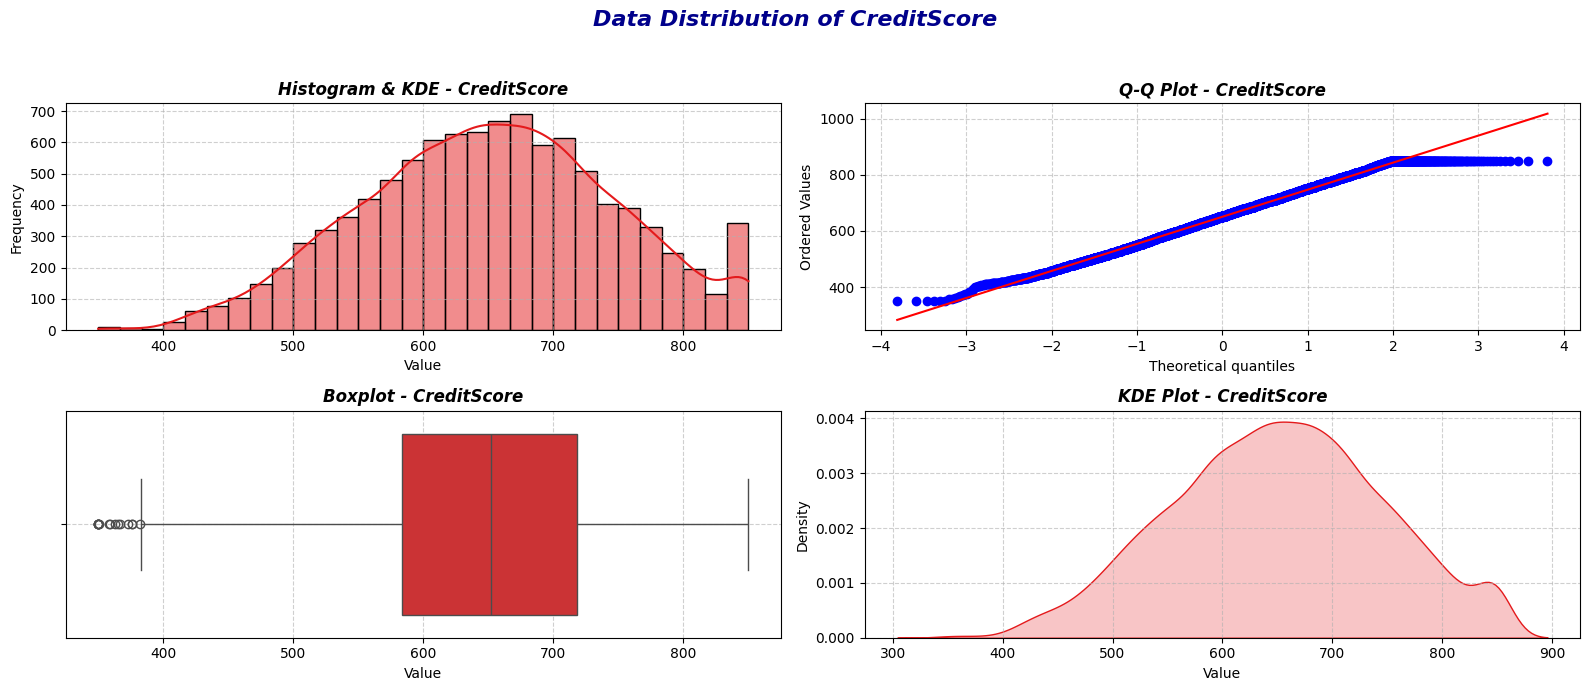



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Age
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9441, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Age: 10.49
Variance of Age: 109.99
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of Age: 1.01
Kurtosis of Age: 1.39
The data is right-skewed (positive skewness). The right tail is longer or has more extreme values.
The data is leptokurtic (kurtosis > 0). 

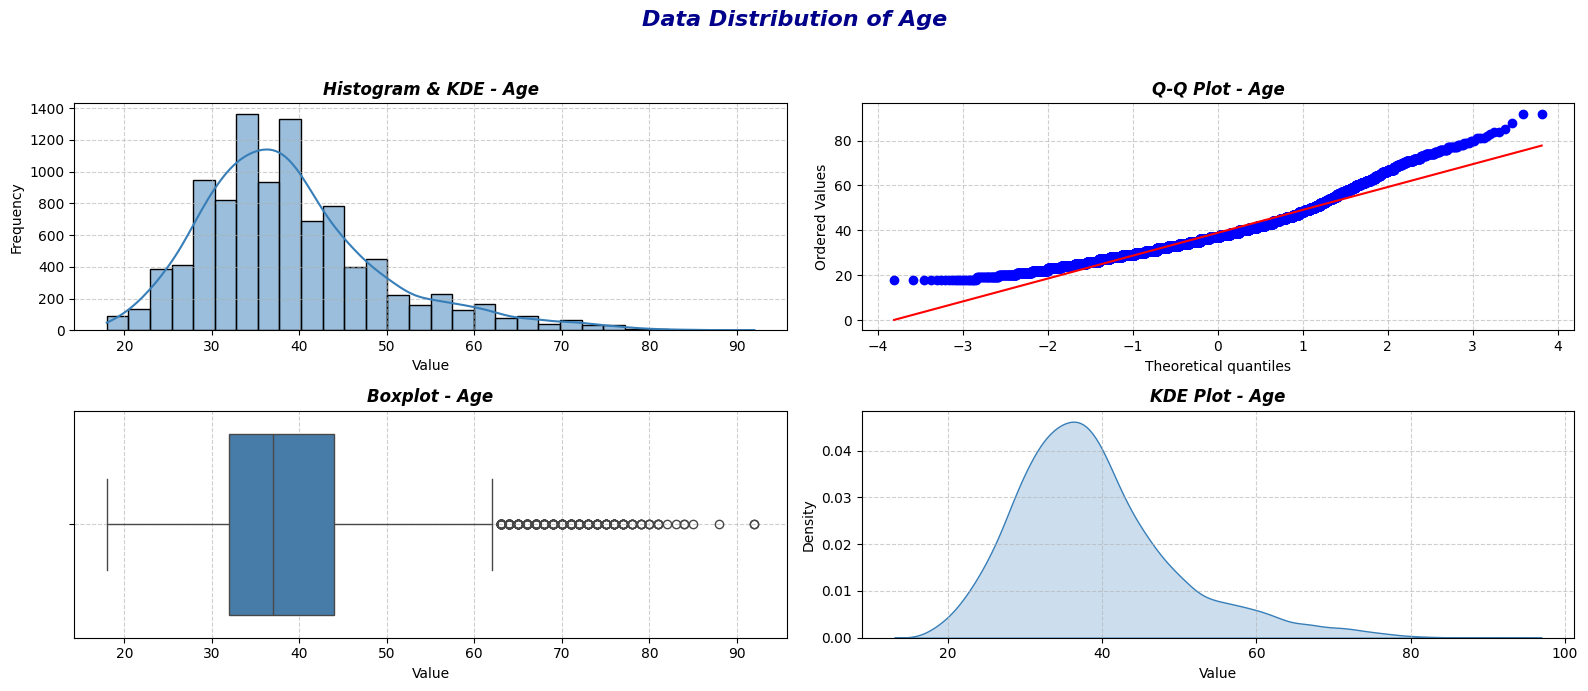



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Tenure
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9486, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Tenure: 2.89
Variance of Tenure: 8.36
The data has moderate variability (1 <= Standard Deviation < 3). Values are spread out but not extreme.
The data has moderate variance (1 <= Variance < 9). The spread of data points is moderate.


Calculating skewness and kurtosis to understand data shape...
Skewness of Tenure: 0.01
Kurtosis of Tenure: -1.17
The data is right-skewed (positive skewness). The right tail is longer or has more extreme values.
The data is p

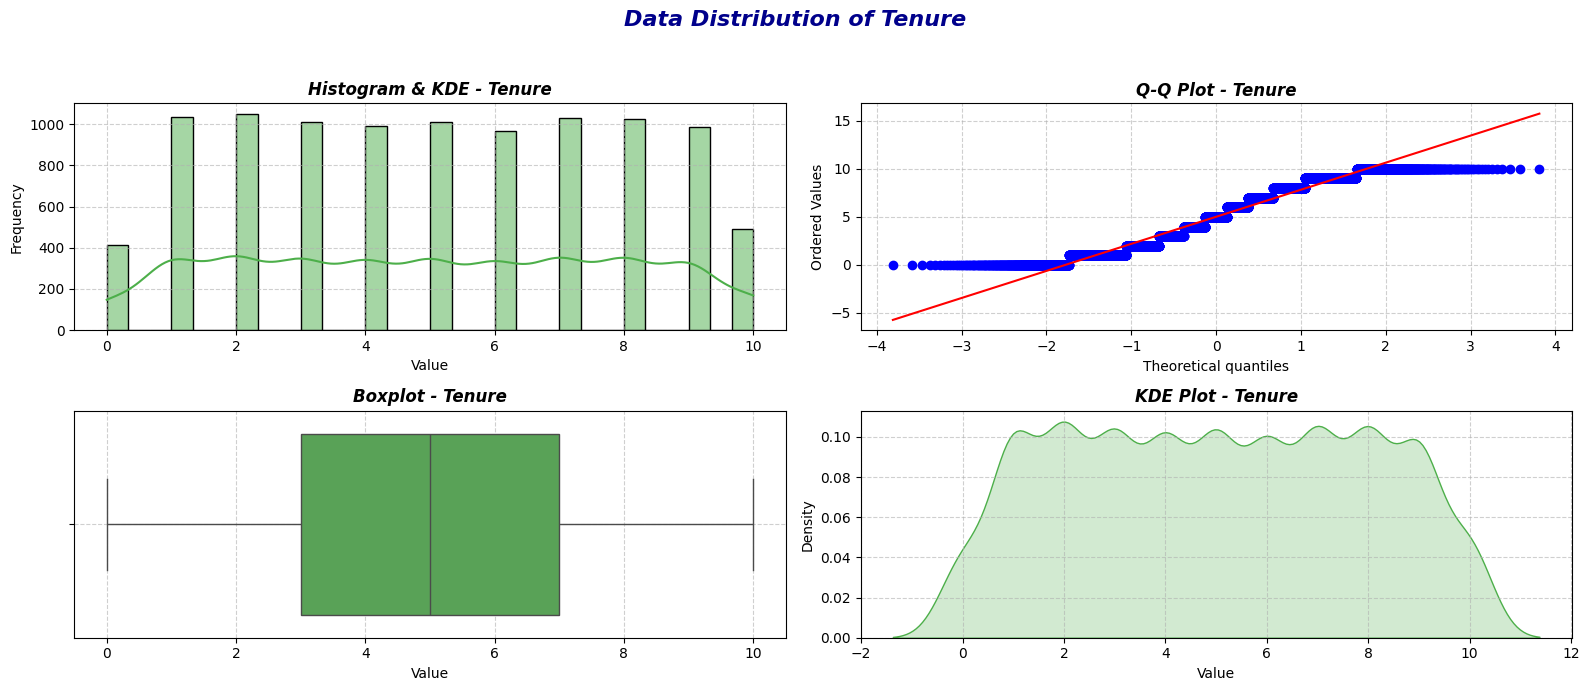



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Balance
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.8456, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Balance: 62397.41
Variance of Balance: 3893436175.99
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of Balance: -0.14
Kurtosis of Balance: -1.49
The data is left-skewed (negative skewness). The left tail is longer or has more extreme values.
The data i

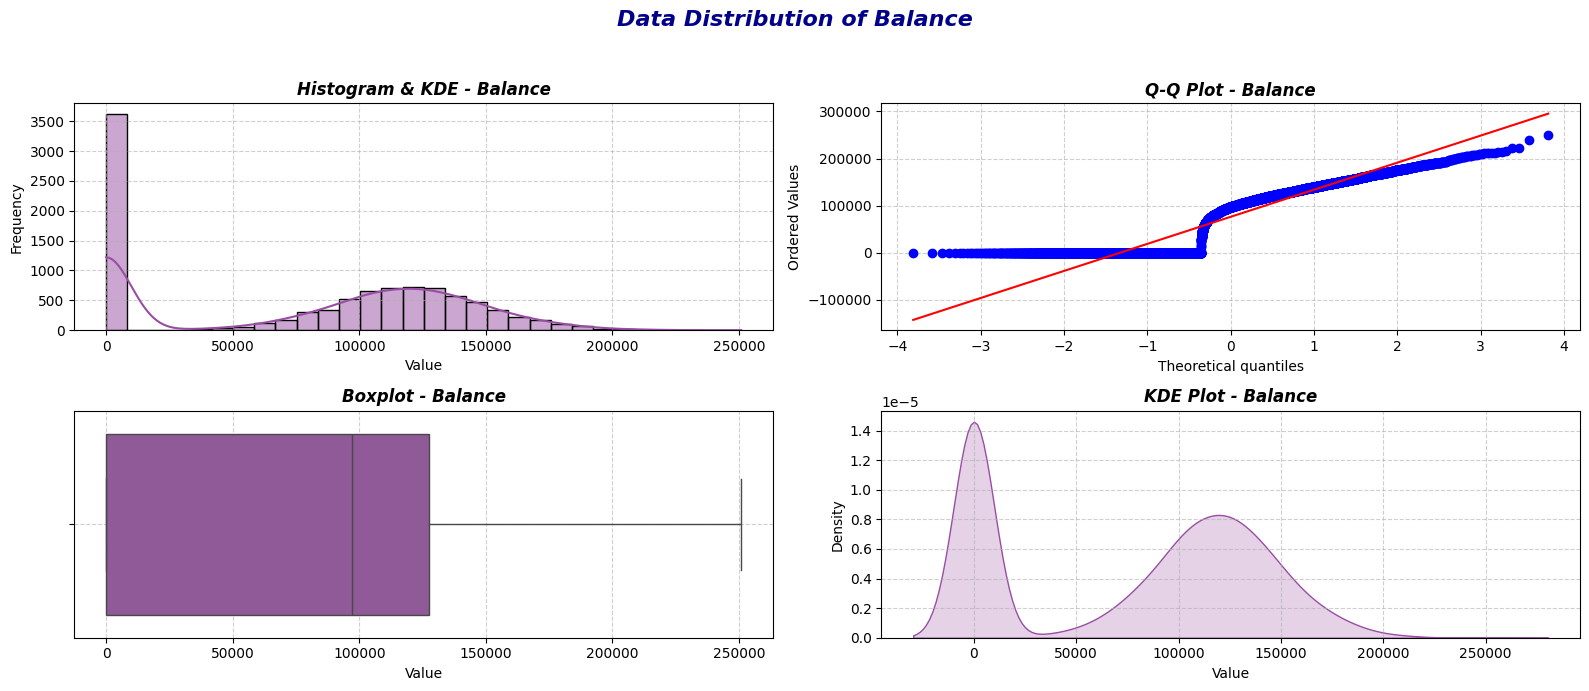



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of EstimatedSalary
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9566, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of EstimatedSalary: 57510.49
Variance of EstimatedSalary: 3307456784.13
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of EstimatedSalary: 0.00
Kurtosis of EstimatedSalary: -1.18
The data is right-skewed (positive skewness). The right tail is long

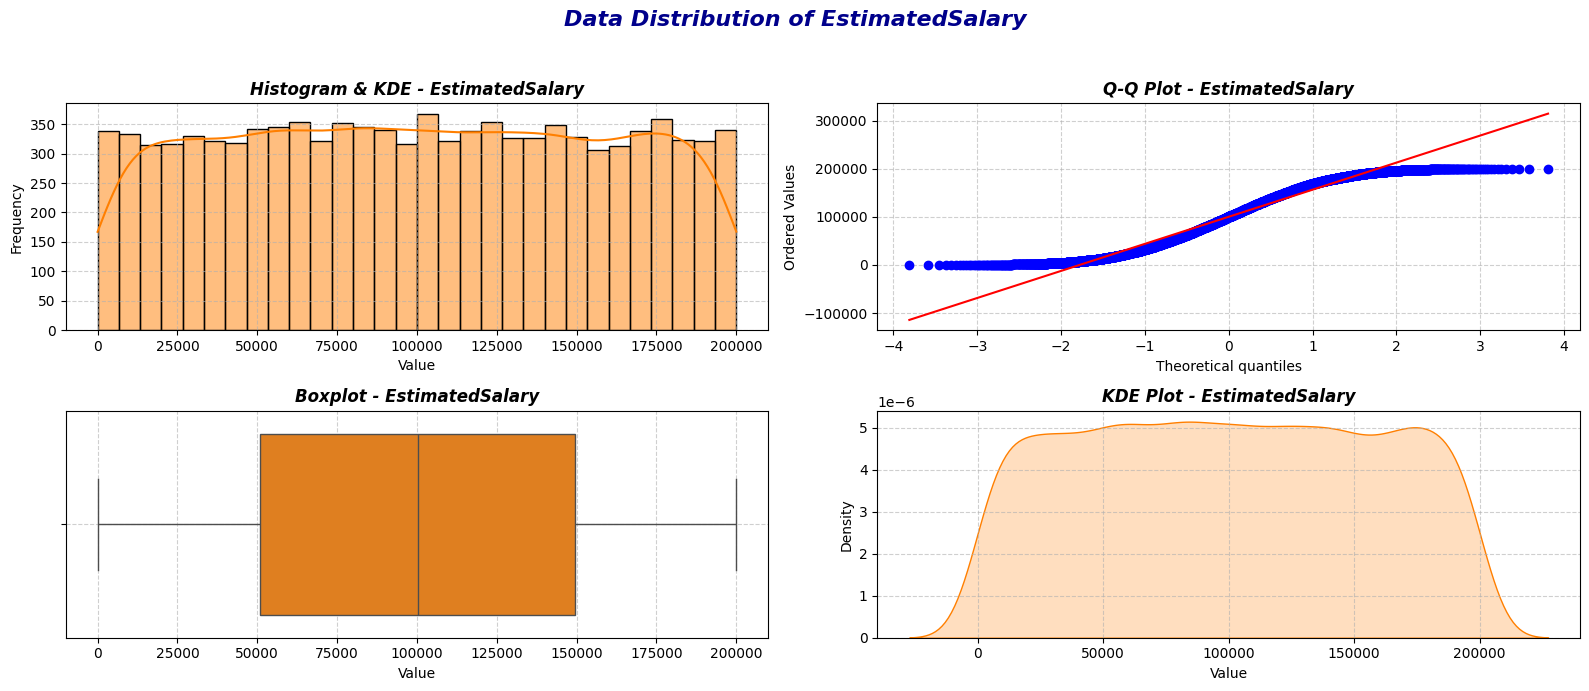



____________________________________________________________________________________________________________________________________________________________________________________




In [33]:
color_map = sns.color_palette("Set1", len(numerical_columns))

# Analyze each numerical column
for idx, col in enumerate(numerical_columns):
    analyze_distribution(data, col, color_map[idx])
    print('_'*180)
    print('\n')



Mean of CreditScore is: 650.5288
Median of CreditScore is: 652.0


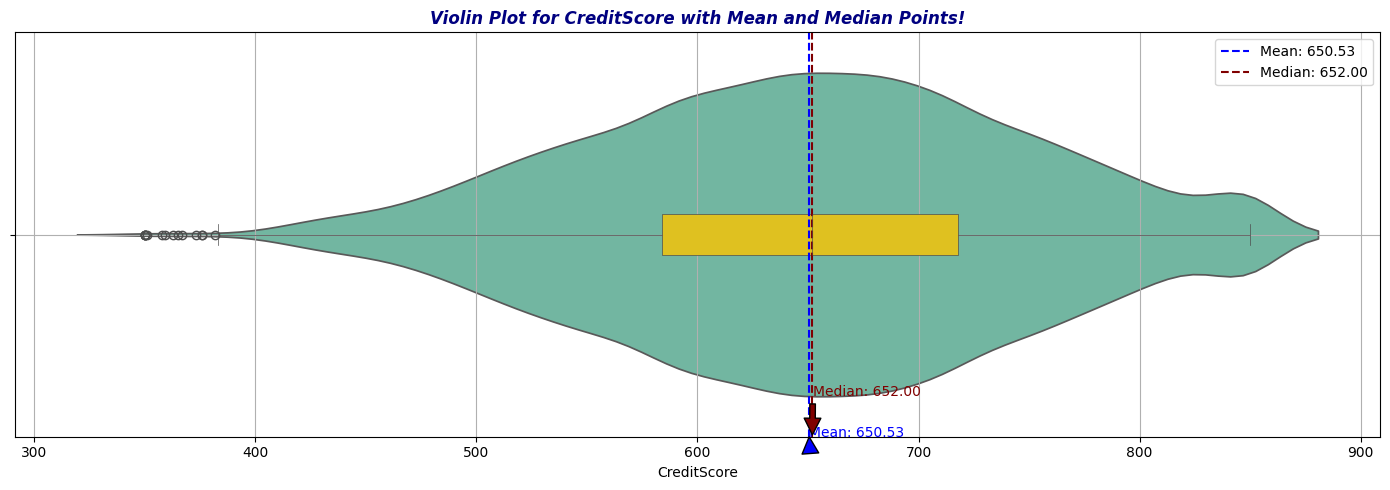

____________________________________________________________________________________________________________________________________________________________________________________


Mean of Age is: 38.9218
Median of Age is: 37.0


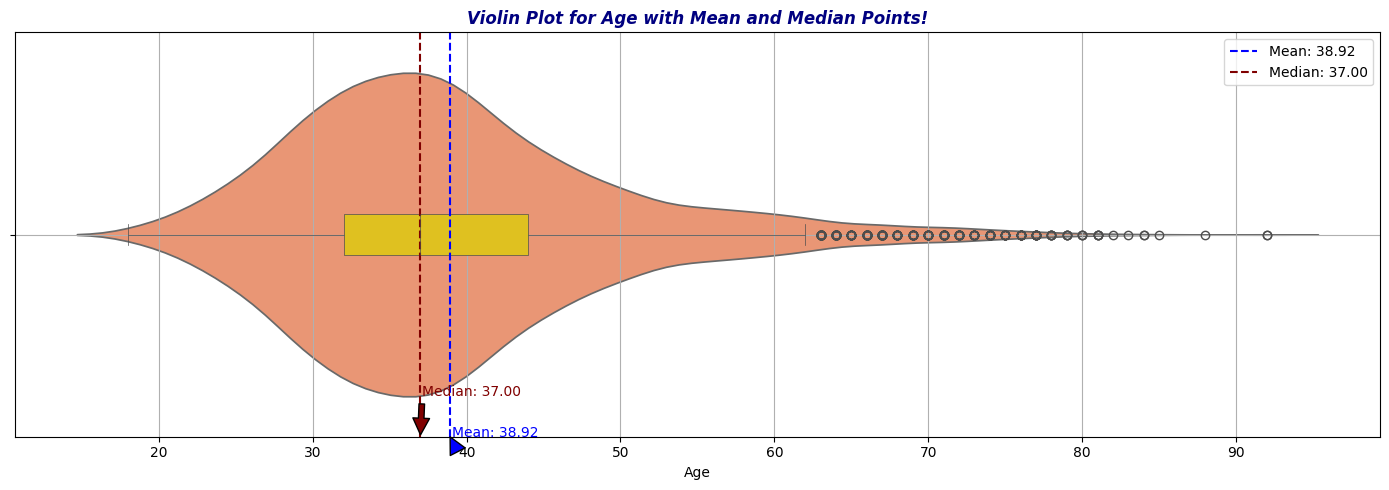

____________________________________________________________________________________________________________________________________________________________________________________


Mean of Tenure is: 5.0128
Median of Tenure is: 5.0


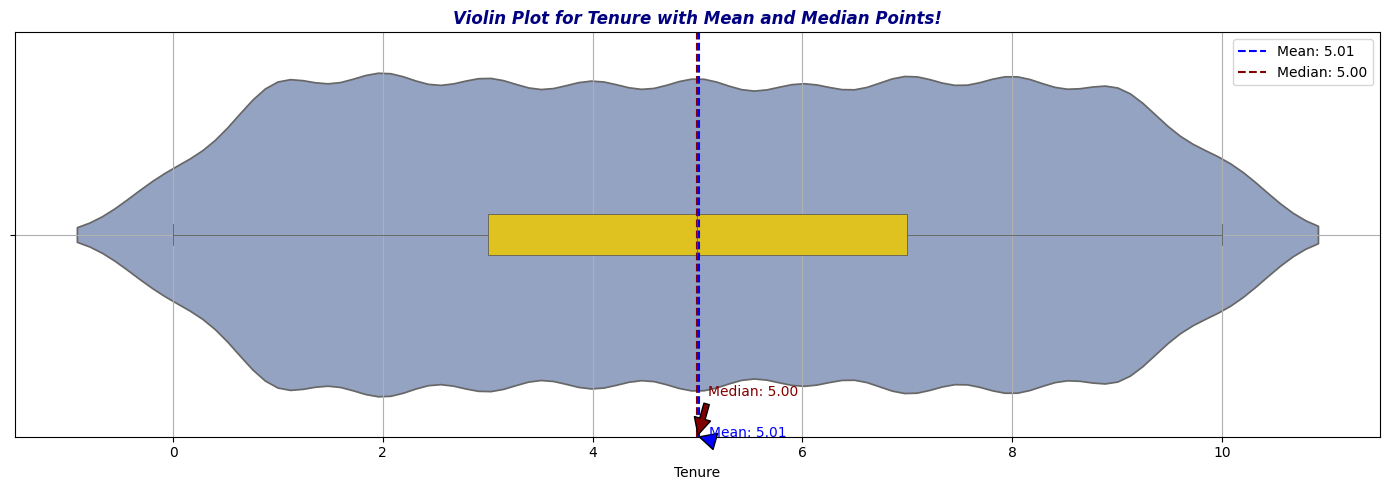

____________________________________________________________________________________________________________________________________________________________________________________


Mean of Balance is: 76485.889288
Median of Balance is: 97198.54000000001


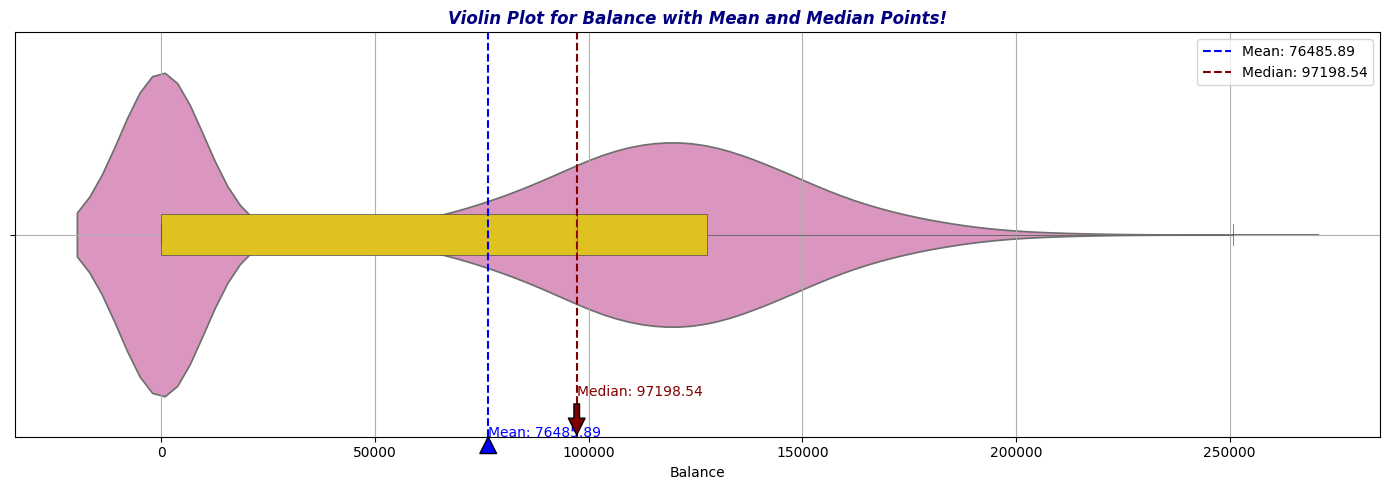

____________________________________________________________________________________________________________________________________________________________________________________


Mean of EstimatedSalary is: 100090.239881
Median of EstimatedSalary is: 100193.915


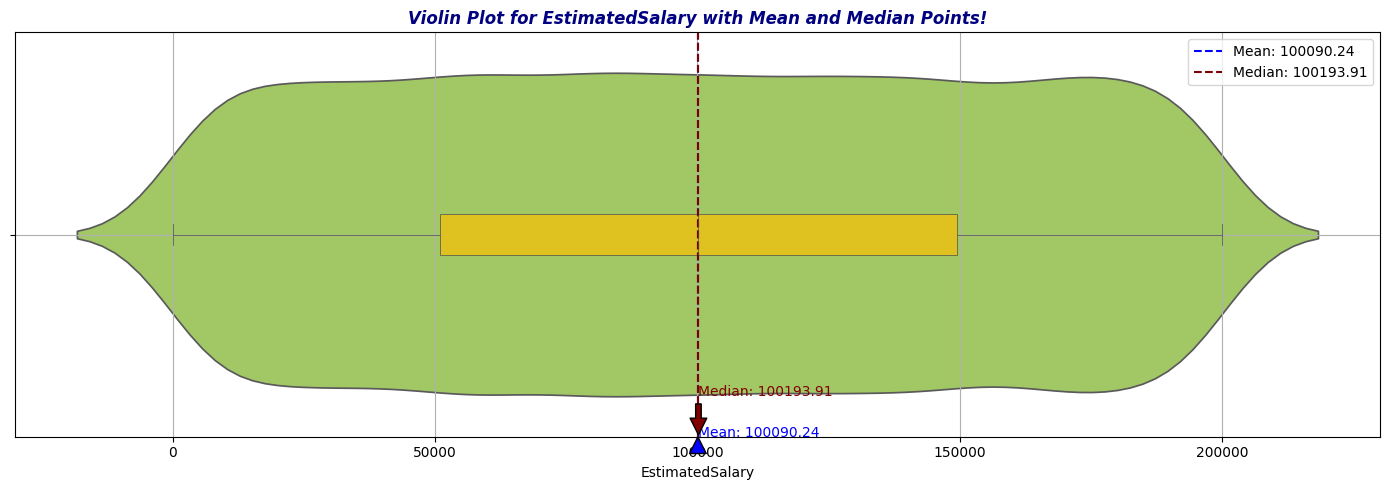

____________________________________________________________________________________________________________________________________________________________________________________


In [34]:
color_map = sns.color_palette("Set2", len(numerical_columns))

# Define color for mean and median lines
mean_color = 'blue'
median_color = 'maroon'

# Create individual plots for each numerical column and print statistics
for idx, col in enumerate(numerical_columns):
    # Calculate mean and median
    col_mean = data[col].mean()
    col_median = data[col].median()
    
    # Print mean and median values
    print("\n")
    print(f"Mean of {col} is: {col_mean}")
    print(f"Median of {col} is: {col_median}")
    
    # Create a new figure and axis for each plot
    plt.figure(figsize=(14, 5))
    
    # Create a violin plot with a boxplot inside it
    sns.violinplot(x=data[col], color=color_map[idx], inner=None)
    sns.boxplot(x=data[col], width=0.1, color='gold', linewidth=0.5)
    
    # Plot mean and median lines
    plt.axvline(col_mean, color=mean_color, linestyle='--', label=f'Mean: {col_mean:.2f}')
    plt.axvline(col_median, color=median_color, linestyle='--', label=f'Median: {col_median:.2f}')
    
    # Add annotations
    plt.annotate(f'Mean: {col_mean:.2f}', xy=(col_mean, 0.5), xytext=(col_mean + 0.1, 0.5),
                 arrowprops=dict(facecolor=mean_color, shrink=0.05), color=mean_color)
    plt.annotate(f'Median: {col_median:.2f}', xy=(col_median, 0.5), xytext=(col_median + 0.1, 0.4),
                 arrowprops=dict(facecolor=median_color, shrink=0.05), color=median_color)
    
    # Add title and legend
    plt.title(f'Violin Plot for {col} with Mean and Median Points!', 
              fontweight='bold', fontstyle='italic', color='navy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print('_'*180)


<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">


<span style="font-family: 'Brush Script MT', cursive; color:pink; font-size: 50px; ">Outlier Detection and Handling</span>
<hr style="border: none; height: 2px; background-color: pink; width: 90%; margin: 2px auto;">

Since we observed outliers only in the 'CreditScore' and 'Age' columns, we will handle outliers exclusively in these two columns.


In [35]:
def cap_outliers_iqr(df, column):
    """
    Detects and caps outliers in a given column using the IQR method.
    
    Parameters:
    df (pd.DataFrame): The dataframe containing the column
    column (str): The name of the column to process
    
    Returns:
    pd.DataFrame: Updated dataframe with outliers capped
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nProcessing '{column}':")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

    # Count outliers before capping
    num_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    print(f"Number of outliers before capping: {num_outliers}")

    # Capping
    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

    # Count after capping (should be 0)
    num_outliers_after = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    print(f"Number of outliers after capping: {num_outliers_after}")

    return df


In [36]:
# Apply capping on CreditScore and Age
data = cap_outliers_iqr(data, 'CreditScore')
data = cap_outliers_iqr(data, 'Age')



Processing 'CreditScore':
Q1: 584.0, Q3: 718.0, IQR: 134.0
Lower Bound: 383.0, Upper Bound: 919.0
Number of outliers before capping: 15
Number of outliers after capping: 0

Processing 'Age':
Q1: 32.0, Q3: 44.0, IQR: 12.0
Lower Bound: 14.0, Upper Bound: 62.0
Number of outliers before capping: 359
Number of outliers after capping: 0



Analyzing Distribution of CreditScore
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9936, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of CreditScore: 96.56
Variance of CreditScore: 9323.58
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of CreditScore: -0.06
Kurtosis of CreditScore: -0.45
The data is left-skewed (negative skewness). The left tail is longer or has more extreme values.
The data is platykurtic (kurtosis < 0). Fewer extreme outliers and a flatter distribution than a normal distribution.


Plotting the distribution of the data...


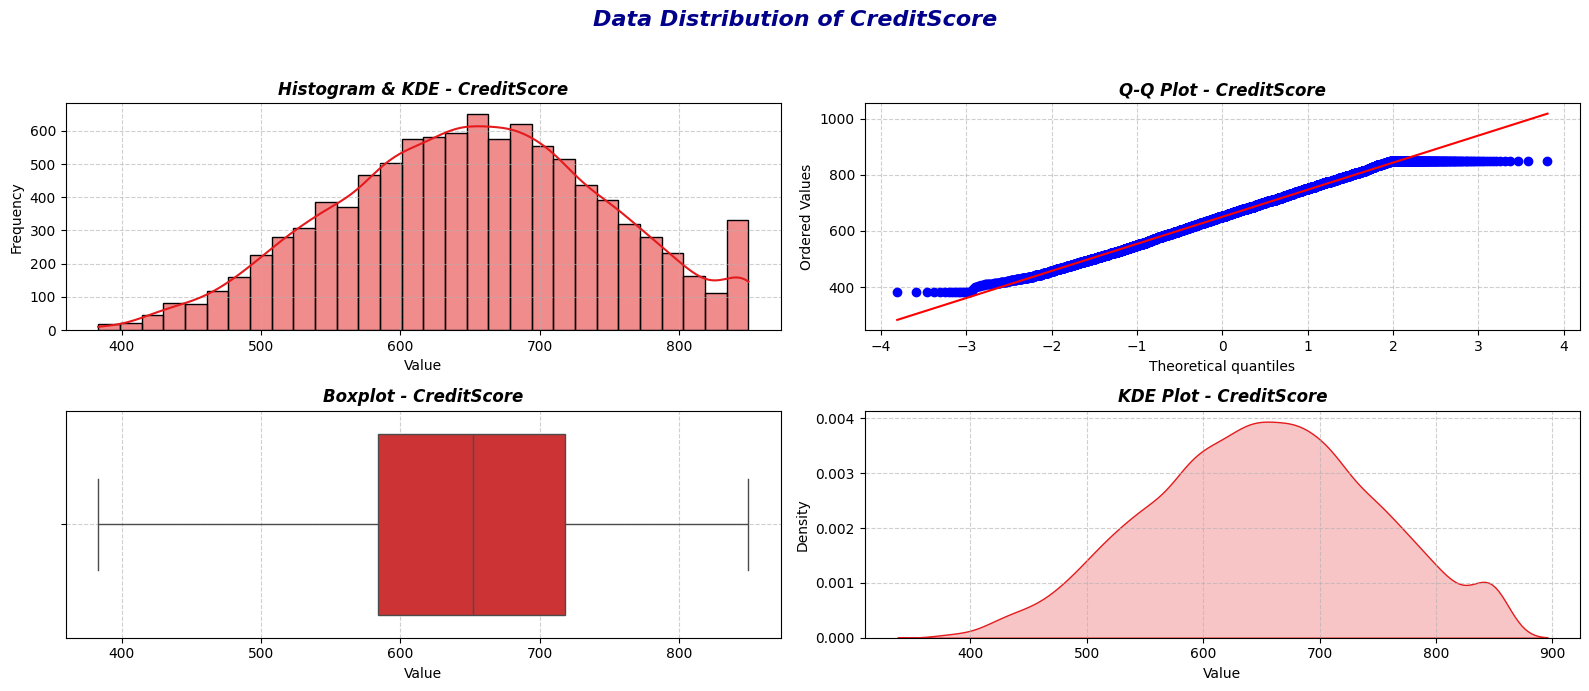



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Age
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9602, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Age: 9.75
Variance of Age: 95.00
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of Age: 0.63
Kurtosis of Age: 0.02
The data is right-skewed (positive skewness). The right tail is longer or has more extreme values.
The data is leptokurtic (kurtosis > 0). Mo

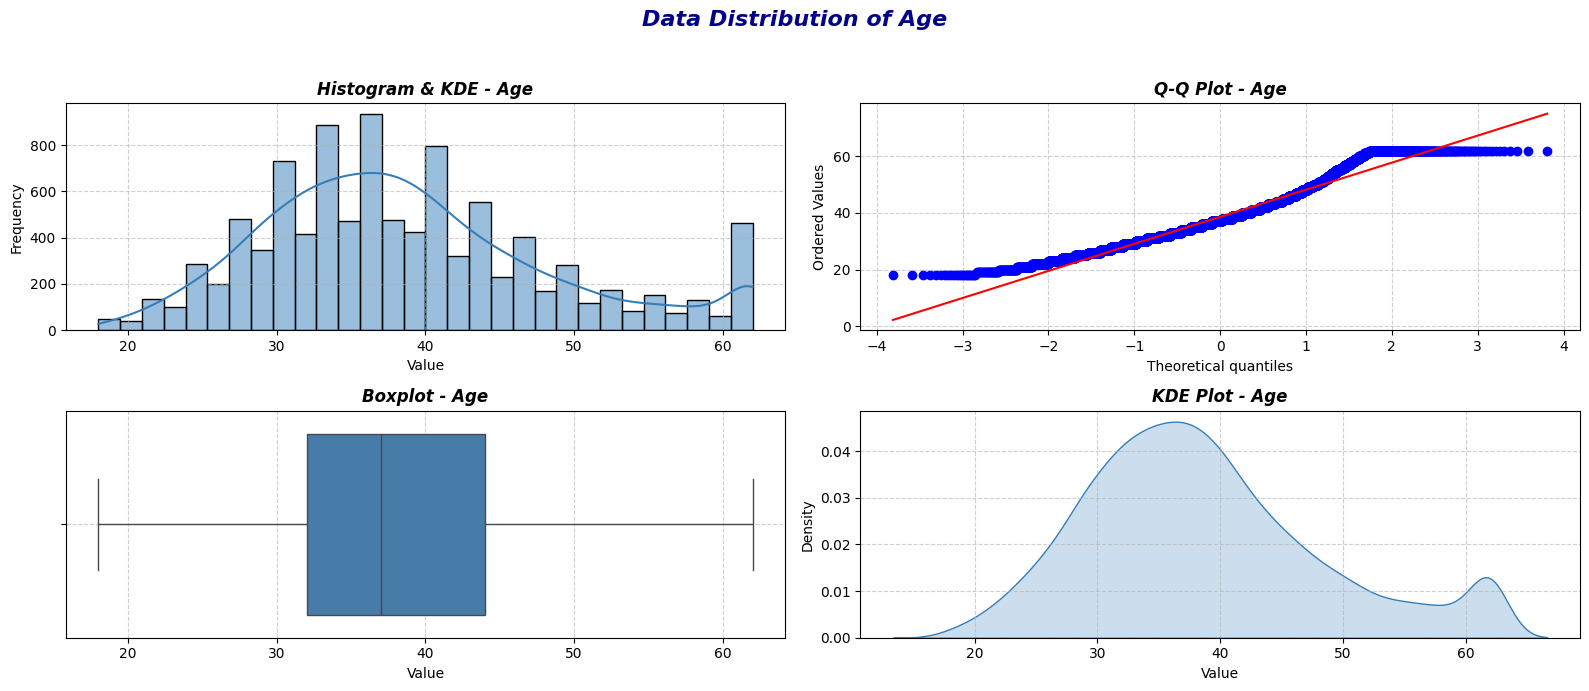



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Tenure
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9486, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Tenure: 2.89
Variance of Tenure: 8.36
The data has moderate variability (1 <= Standard Deviation < 3). Values are spread out but not extreme.
The data has moderate variance (1 <= Variance < 9). The spread of data points is moderate.


Calculating skewness and kurtosis to understand data shape...
Skewness of Tenure: 0.01
Kurtosis of Tenure: -1.17
The data is right-skewed (positive skewness). The right tail is longer or has more extreme values.
The data is p

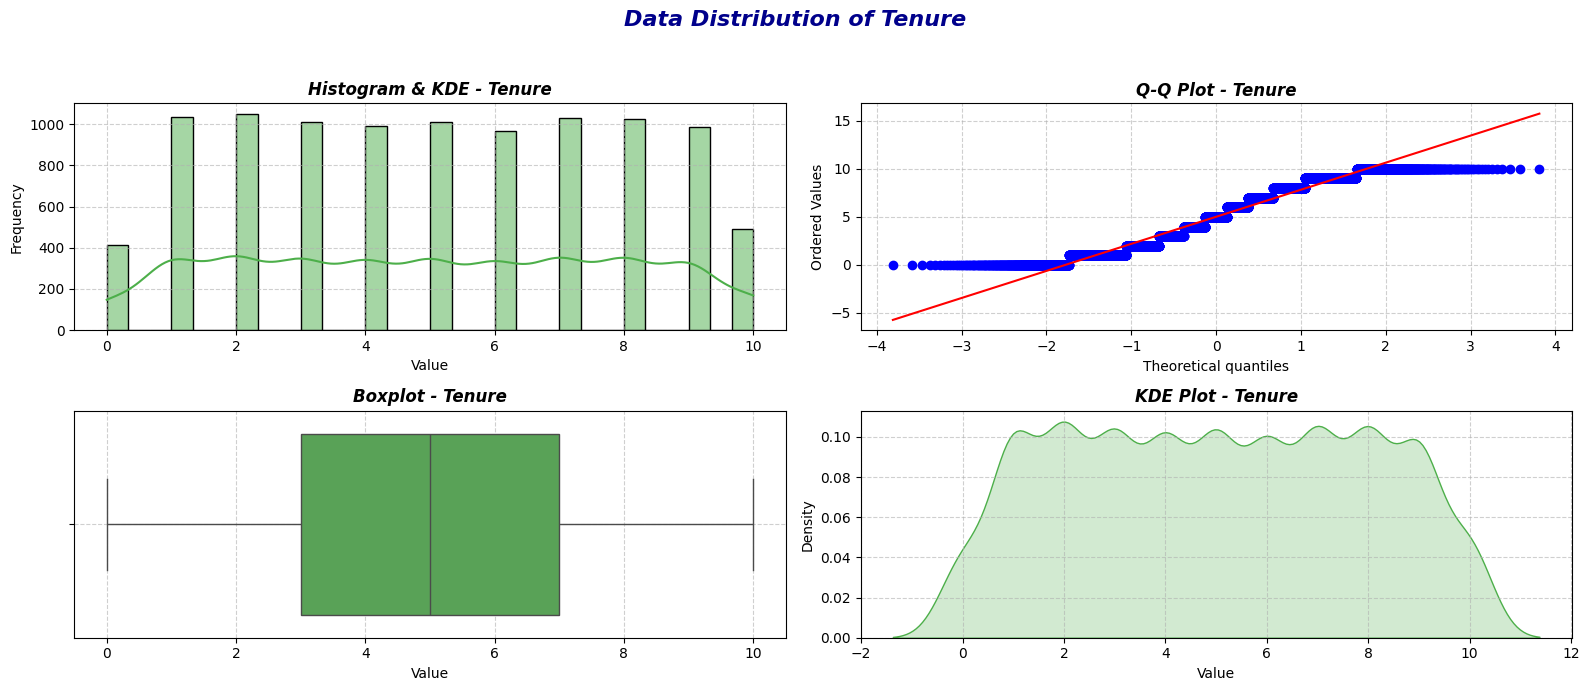



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of Balance
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.8456, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of Balance: 62397.41
Variance of Balance: 3893436175.99
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of Balance: -0.14
Kurtosis of Balance: -1.49
The data is left-skewed (negative skewness). The left tail is longer or has more extreme values.
The data i

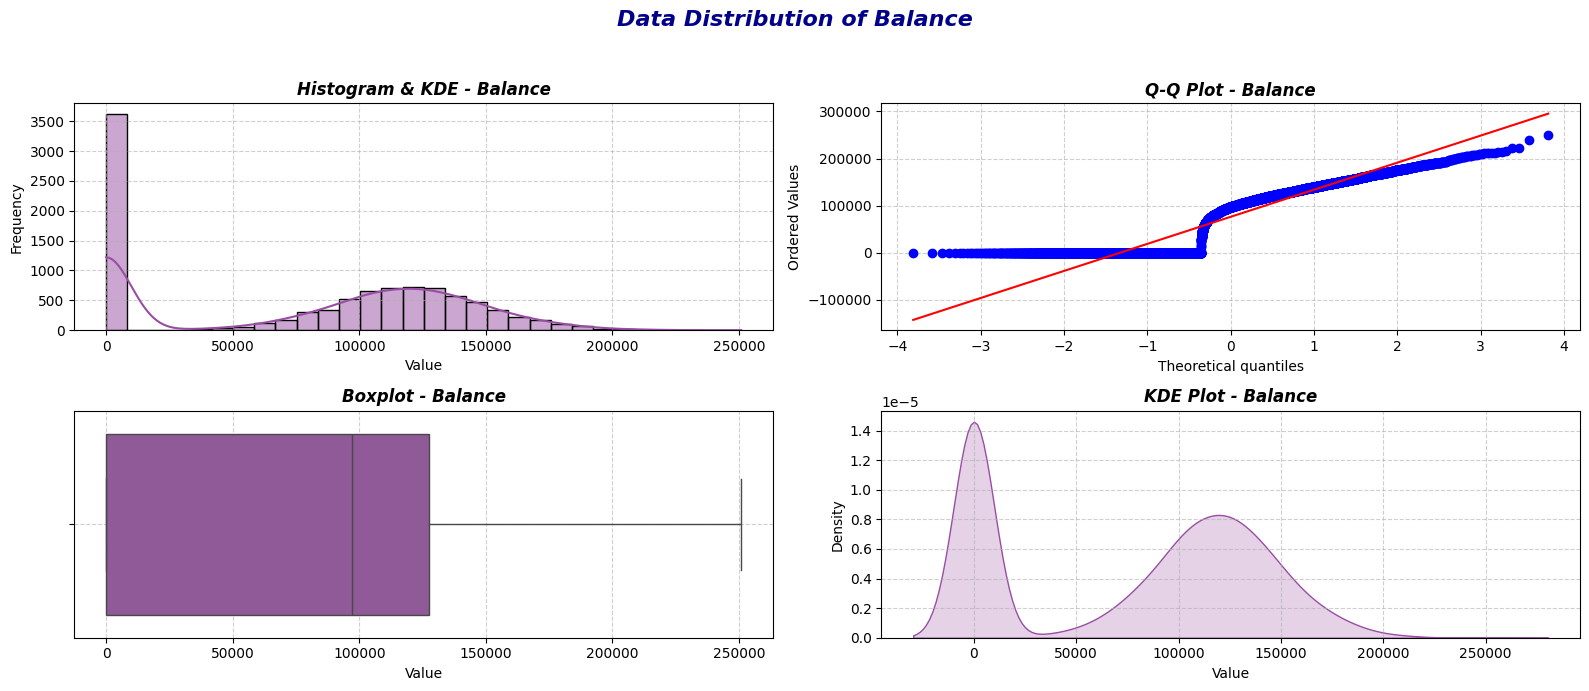



____________________________________________________________________________________________________________________________________________________________________________________



Analyzing Distribution of EstimatedSalary
Determining if the data follows a normal distribution...
Shapiro-Wilk Test:
Statistic: 0.9566, P-value: 0.0000
Conclusion: The data is not normally distributed (p-value ≤ 0.05).

The data follows a normal distribution : False
Calculating standard deviation and variance to understand data spread...
Standard Deviation of EstimatedSalary: 57510.49
Variance of EstimatedSalary: 3307456784.13
The data has high variability (Standard Deviation >= 3). Values are widely spread out from the mean.
The data has high variance (Variance >= 9). The spread of data points is large.


Calculating skewness and kurtosis to understand data shape...
Skewness of EstimatedSalary: 0.00
Kurtosis of EstimatedSalary: -1.18
The data is right-skewed (positive skewness). The right tail is long

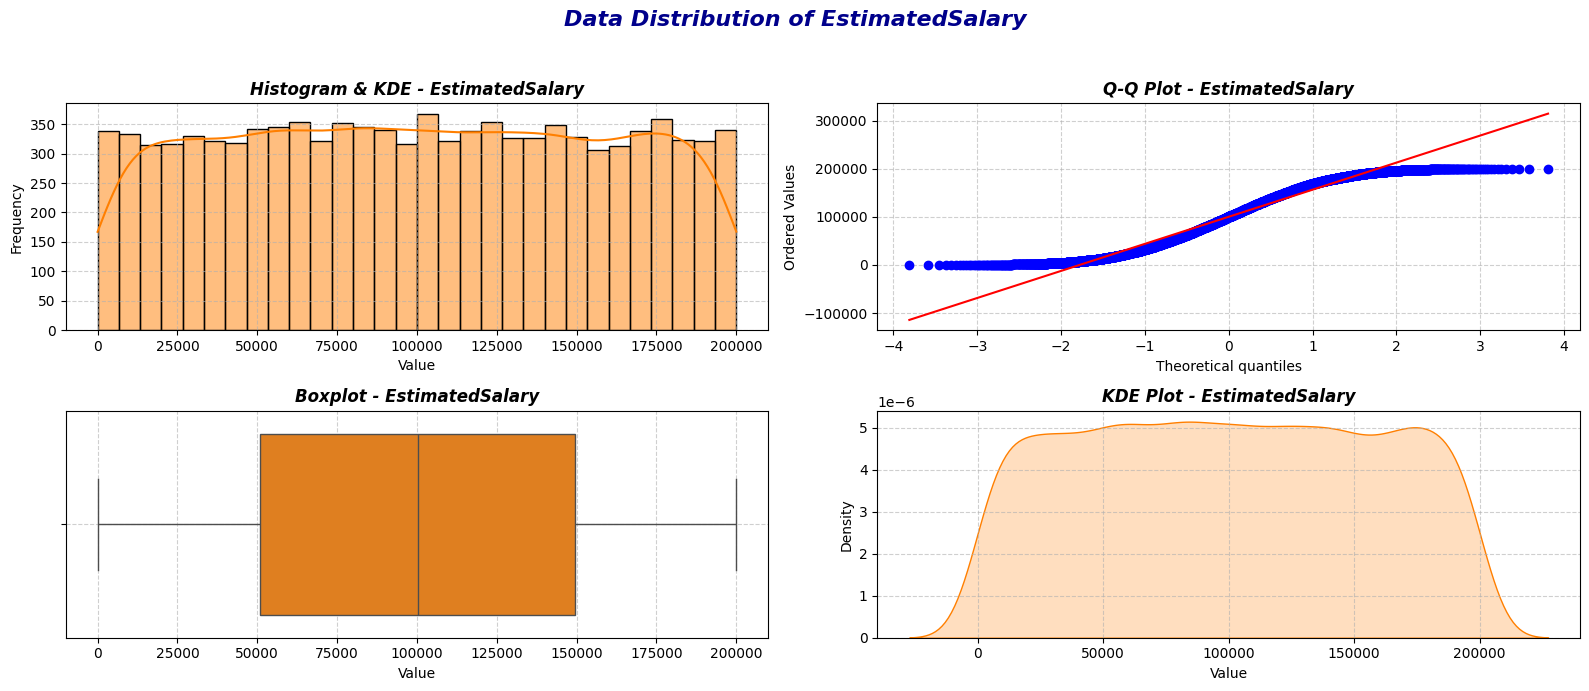



____________________________________________________________________________________________________________________________________________________________________________________




In [37]:
color_map = sns.color_palette("Set1", len(numerical_columns))

# Analyze each numerical column
for idx, col in enumerate(numerical_columns):
    analyze_distribution(data, col, color_map[idx])
    print('_'*180)
    print('\n')

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<span style="font-family: 'Brush Script MT', cursive; color:pink; font-size: 50px; ">Categorical Features Distribution</span>
<hr style="border: none; height: 2px; background-color: pink; width: 90%; margin: 2px auto;">

The Number of Unique elements present in the 'Geography' column are: 3


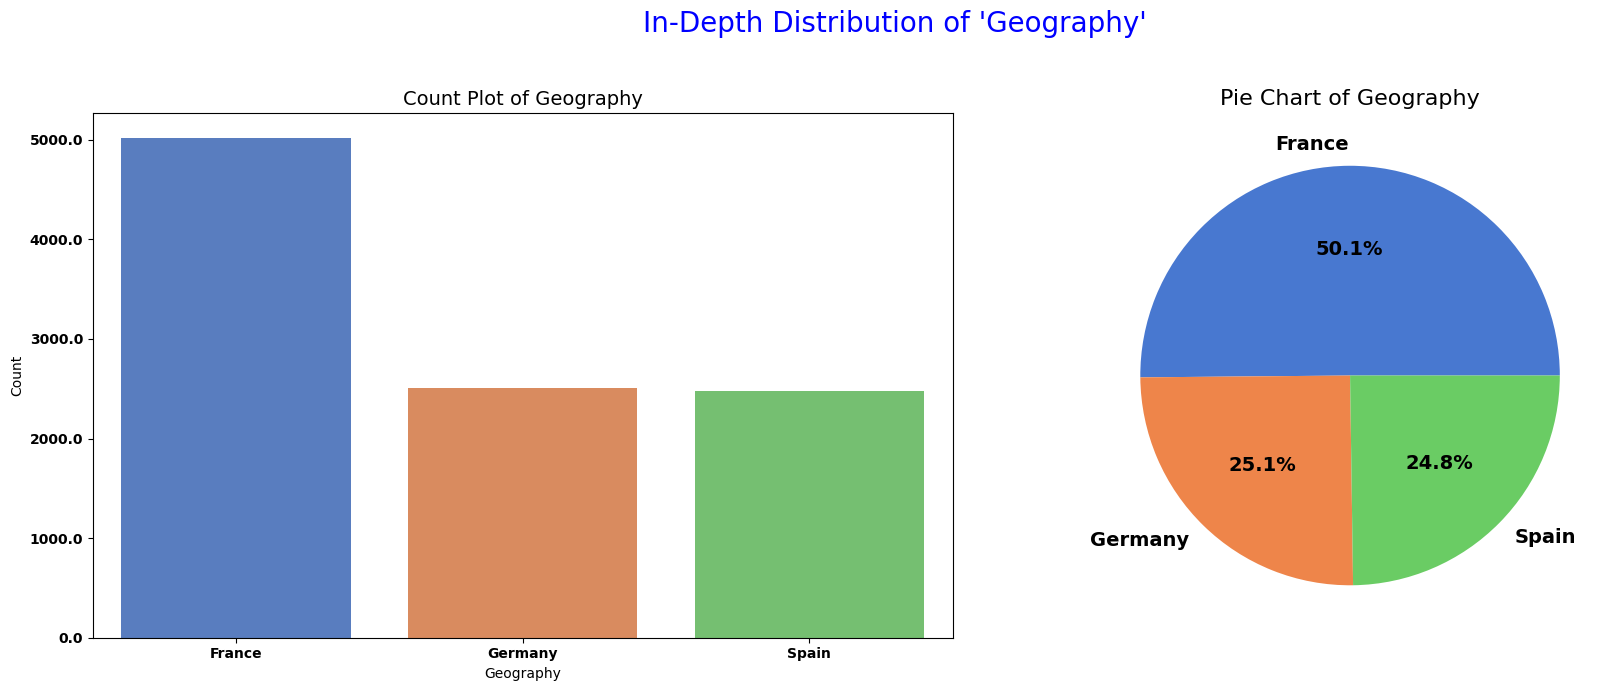



The Number of Unique elements present in the 'Gender' column are: 2


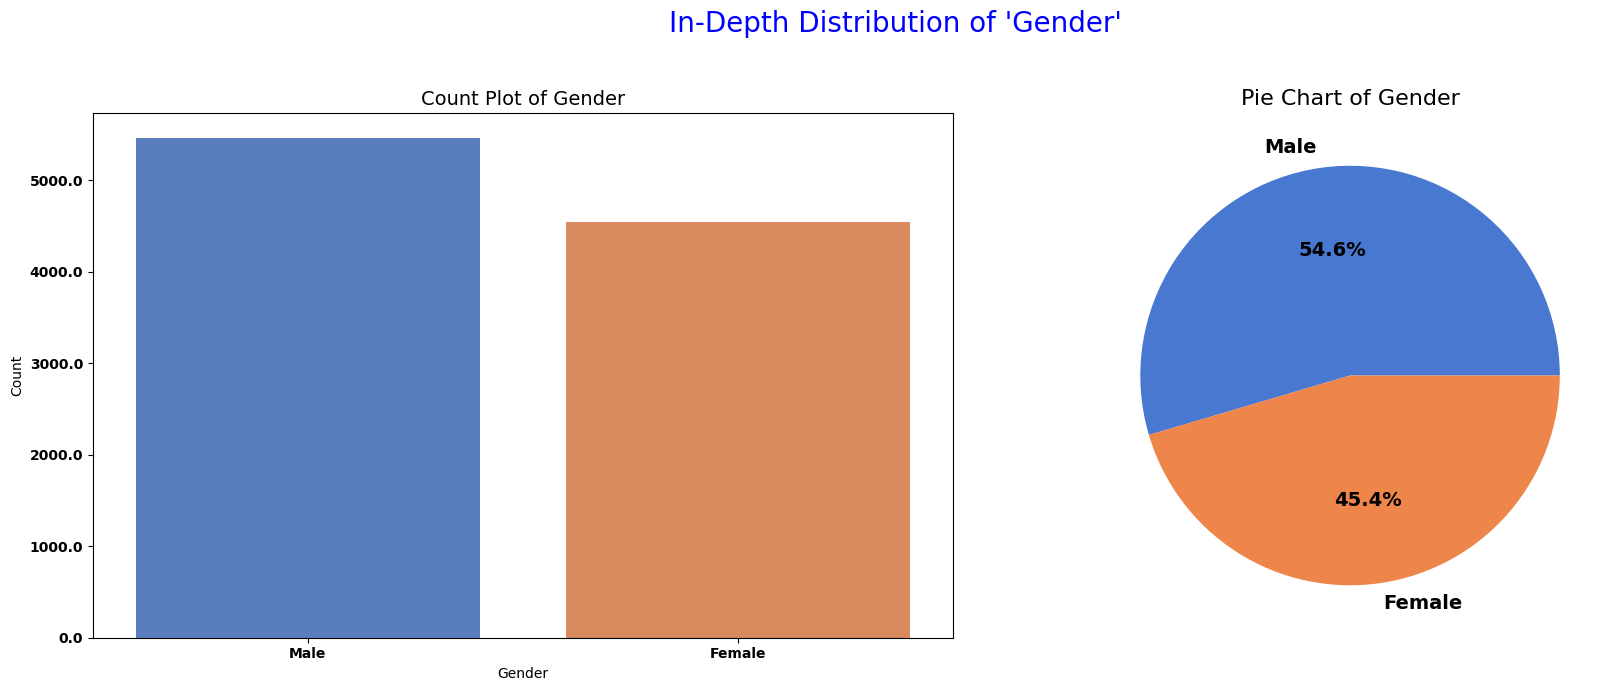



The Number of Unique elements present in the 'NumOfProducts' column are: 4


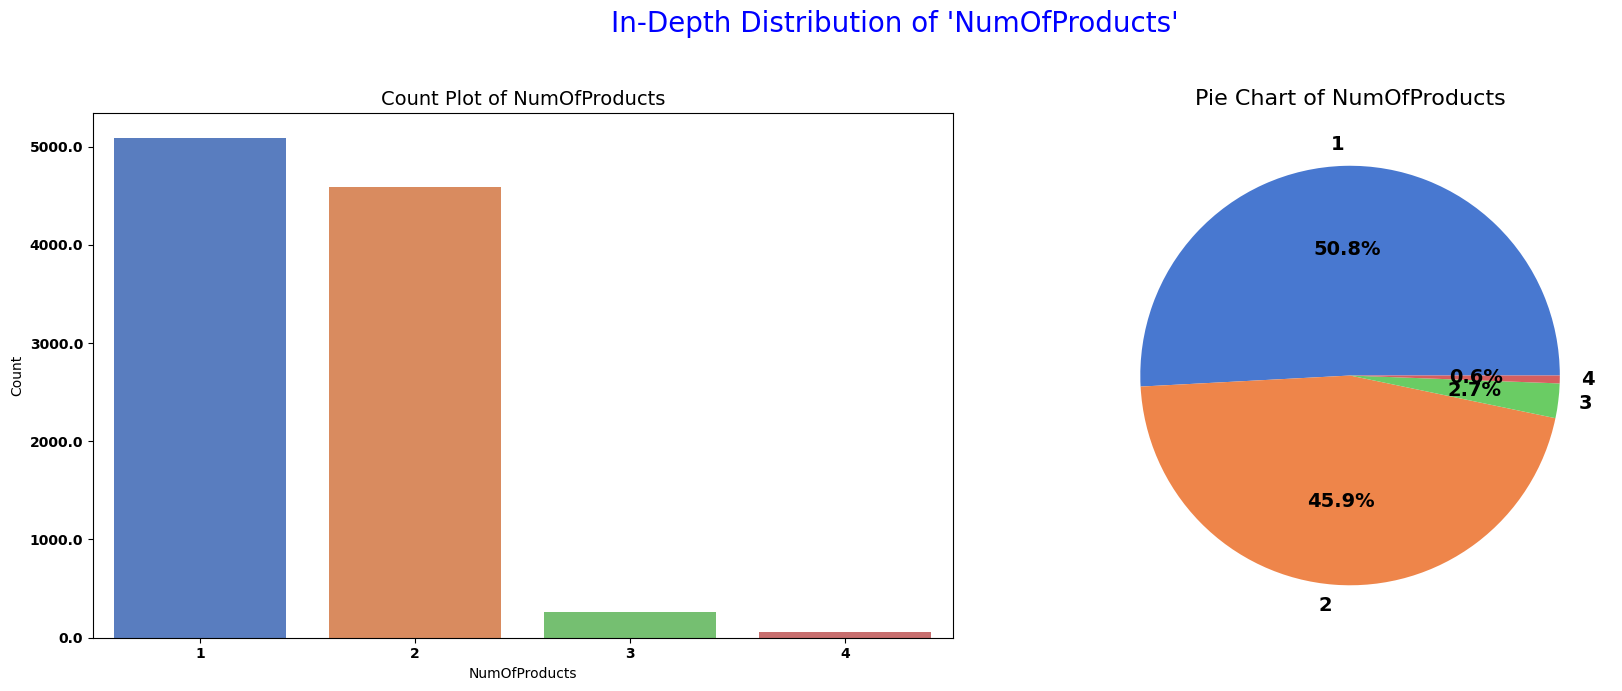



The Number of Unique elements present in the 'HasCrCard' column are: 2


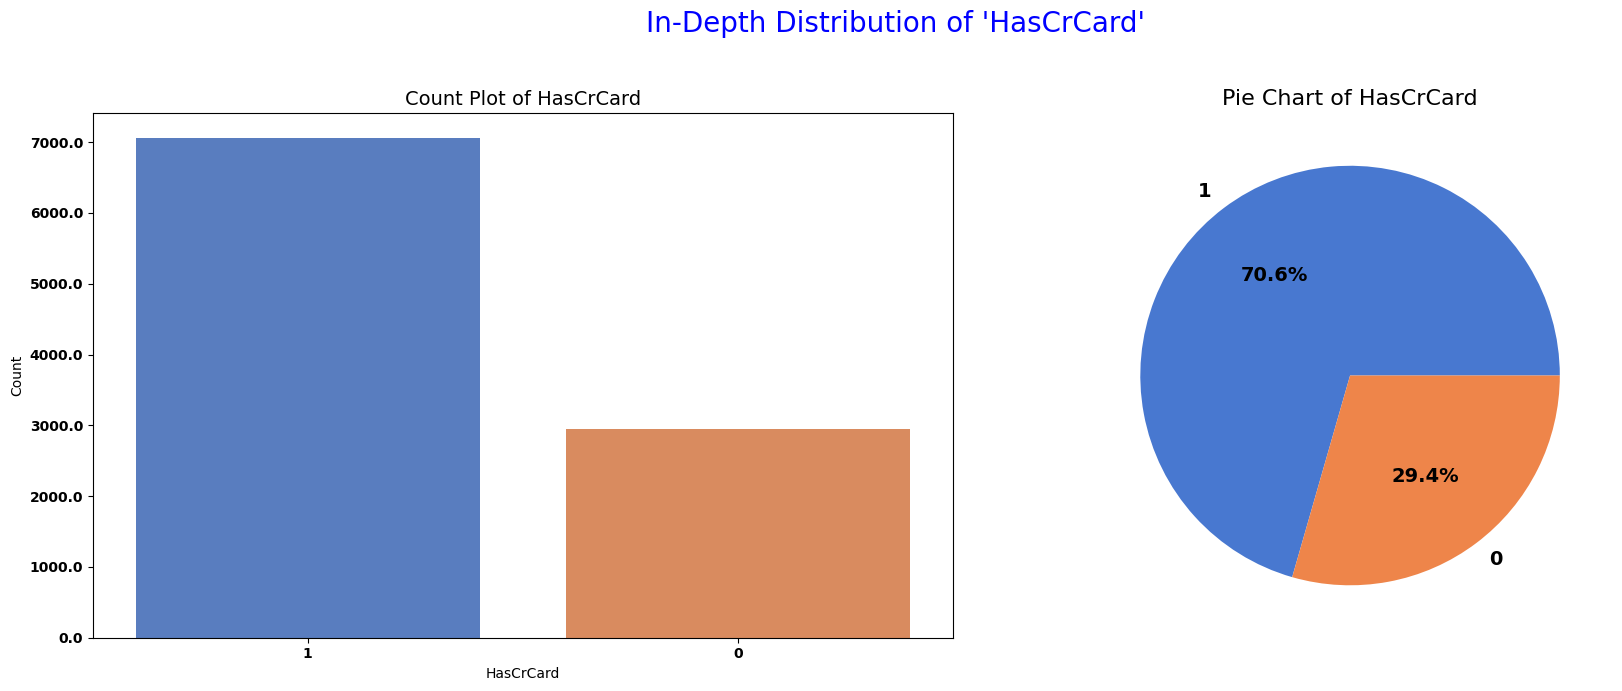



The Number of Unique elements present in the 'IsActiveMember' column are: 2


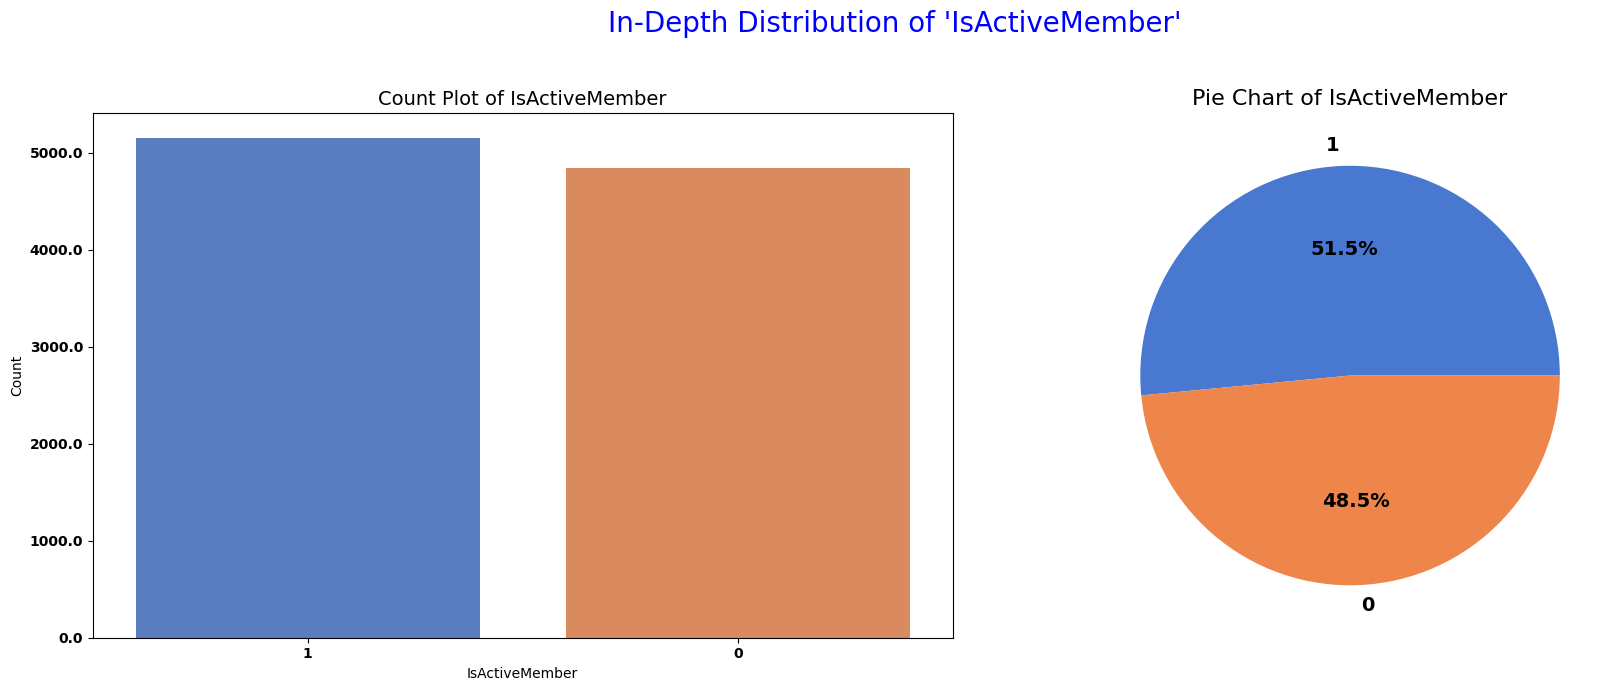



The Number of Unique elements present in the 'Exited' column are: 2


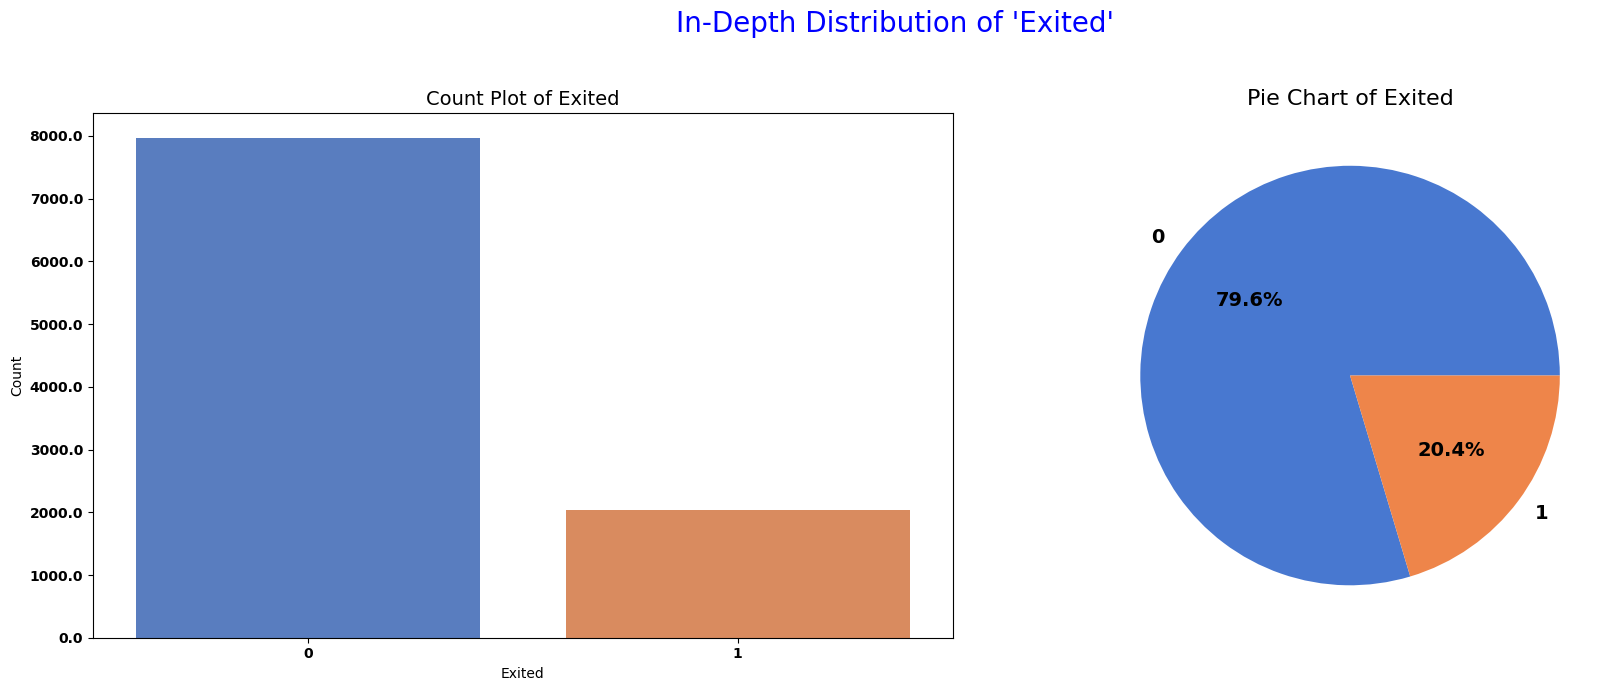

In [38]:
# Loop through each categorical column with <= 5 unique values
for column in categorical_columns:
    if data[column].nunique() <= 5:
        print(f"The Number of Unique elements present in the '{column}' column are: {data[column].nunique()}")

        # Get value counts and sort descending
        sorted_counts = data[column].value_counts().sort_values(ascending=False)

        # Create subplot: 1 row, 2 columns
        fig, axes = plt.subplots(1, 2, figsize=(18,7))

        # Bar Chart
        sns.countplot(data=data, x=column, order=sorted_counts.index, palette='muted', ax=axes[0])
        axes[0].set_title(f"Count Plot of {column}", fontsize=14)
        axes[0].set_ylabel('Count')
        axes[0].set_xlabel(column)
        
        # Bold Y-tick labels
        axes[0].set_yticklabels(axes[0].get_yticks(), fontweight='bold')

        # Bold X-tick labels
        axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold')

        # Pie Chart
        axes[1].pie(sorted_counts.values, labels=[str(i) for i in sorted_counts.index],
                    autopct='%1.1f%%', colors=sns.color_palette('muted'),textprops={'fontsize': 14 ,'color': 'black', 'weight': 'bold'})
        axes[1].set_title(f"Pie Chart of {column}", fontsize=16)

        # Layout adjustment
        plt.suptitle(f"In-Depth Distribution of '{column}'",fontsize=20, color='Blue')
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Give space for suptitle
        plt.show()

        print('=' * 160)
        print('\n')


<span style="font-family: 'Brush Script MT', cursive; color:pink; font-size: 50px;">Correlation Uncovered</span>
<hr style="border: none; height: 2px; background-color: pink; width: 90%; margin: 2px auto;">

| Variable Type            | Method                    | Function / Tool                    | Description                                                             |
|---------------------------|----------------------------|-------------------------------------|-------------------------------------------------------------------------|
| Num ↔ Num                 | Pearson / Spearman         | `df.corr()`                        | Measures linear (Pearson) or rank-based (Spearman) relationships.       |
| Cat ↔ Cat                 | Cramér's V                 | `dython.nominal.associations()`    | Measures strength of association between categorical variables.        |
| Cat ↔ Num                 | Correlation Ratio (η²)     | `dython.nominal.associations()`    | Measures how much numeric variable varies by categories.               |
| Cat ↔ Cat (directional)   | Theil’s U (asymmetric)     | Manual / `dython.nominal.theils_u()` | Useful when you want to predict one category from another (not symmetric). |


In [39]:
# Calculating the Pearson correlation matrix 
correlation_matrix = numerical_data.corr(method='pearson')  # or 'spearman'
print("Correlation Matrix for  Columns:")
correlation_matrix


Correlation Matrix for  Columns:


,CreditScore,Age,Tenure,Balance,EstimatedSalary
CreditScore,1.000000,-0.003965,0.000842,0.006268,-0.001384
Age,-0.003965,1.000000,-0.009997,0.028308,-0.007201
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.007784
Balance,0.006268,0.028308,-0.012254,1.000000,0.012797
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,1.000000


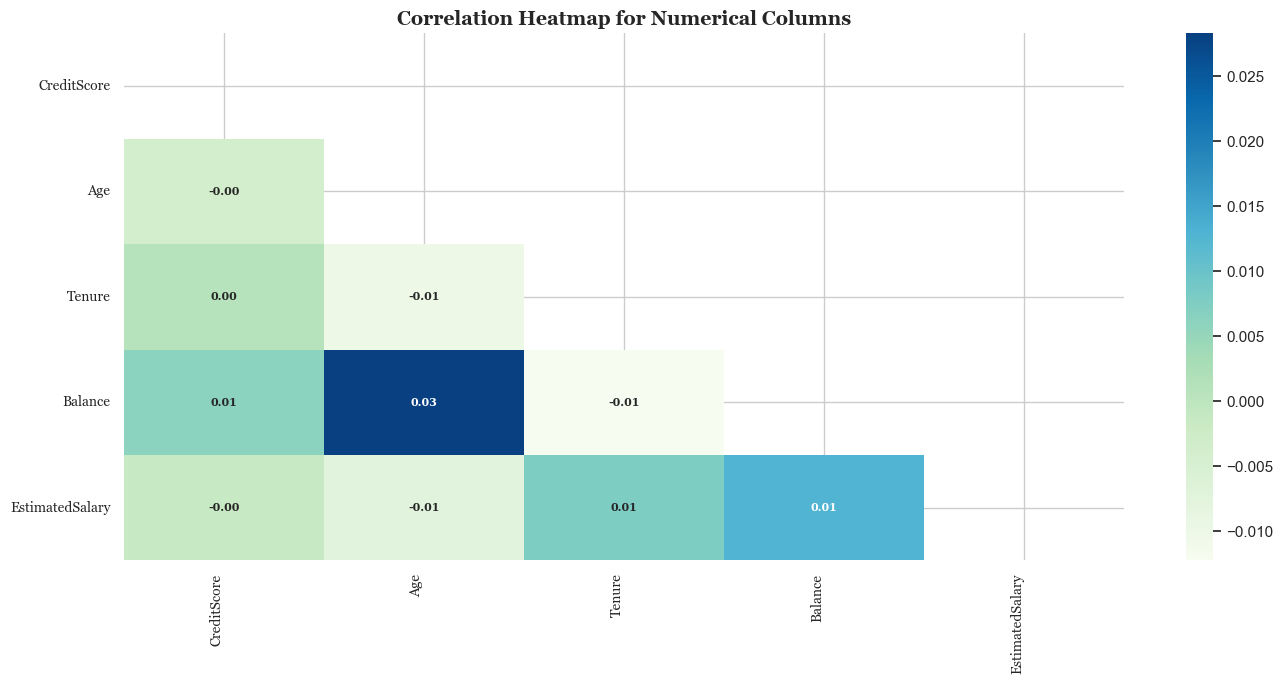

In [40]:
sns.set_theme(style="whitegrid")
corr_matrix = numerical_data.corr()

# Mask the upper triangle to focus on the lower half of the correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(14,7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='GnBu',
    fmt='.2f', 
    annot_kws={"size": 8, "weight": "bold", "family": "serif"},
    mask=mask  # Mask applied to display only the lower half of the correlation matrix
)

plt.title('Correlation Heatmap for Numerical Columns', 
          fontsize=14, fontweight='bold', family='Georgia')

plt.xticks(rotation=90, ha='right', fontsize=10, family='Georgia') 
plt.yticks(rotation=0, fontsize=10, family='Georgia')
plt.tight_layout()
plt.show()



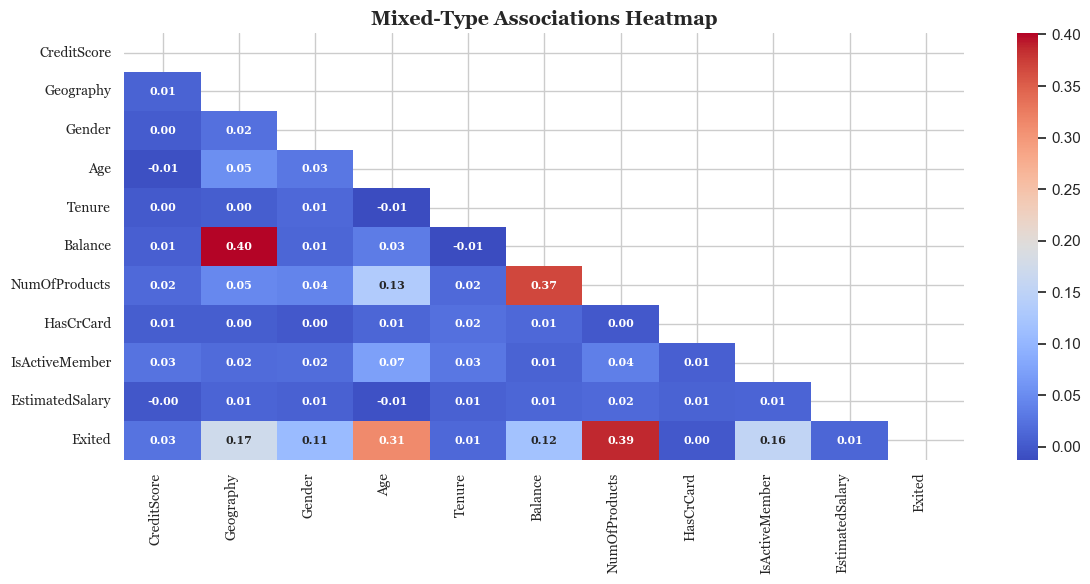

In [41]:
from dython.nominal import associations

# Get associations without plotting
assoc_result = associations(data, nominal_columns='auto', plot=False)
assoc_matrix = assoc_result['corr']

# Create mask for upper triangle
mask = np.triu(np.ones_like(assoc_matrix, dtype=bool))

# Plot styled heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    assoc_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8, "weight": "bold", "family": "serif"},
    mask=mask
)

plt.title("Mixed-Type Associations Heatmap", fontsize=14, fontweight="bold", family="Georgia")
plt.xticks(rotation=90, ha="right", fontsize=10, family="Georgia")
plt.yticks(rotation=0, fontsize=10, family="Georgia")
plt.tight_layout()
plt.show()

In [42]:
# Generate the correlation/association matrix
assoc_result = associations(data, nominal_columns='auto', plot=False)

# Extract only the correlation matrix
assoc_matrix = assoc_result['corr']

# Mask the upper triangle (keep only lower triangle)
mask = np.triu(np.ones_like(assoc_matrix, dtype=bool))
triangular_assoc = assoc_matrix.where(~mask)

# Flatten the triangular matrix
assoc_pairs = triangular_assoc.stack().reset_index()
assoc_pairs.columns = ['Column_1', 'Column_2', 'Association_Score']

# Drop self-correlations (diagonal elements)
assoc_pairs = assoc_pairs[assoc_pairs['Column_1'] != assoc_pairs['Column_2']]

# Sort by absolute association score
assoc_pairs_sorted = assoc_pairs.loc[
    assoc_pairs['Association_Score'].abs().sort_values(ascending=False).index
]

# Top 10 strongest associations
top_associations = assoc_pairs_sorted.head(10).reset_index(drop=True)

top_associations

,Column_1,Column_2,Association_Score
0,Balance,Geography,0.401114
1,Exited,NumOfProducts,0.387399
2,NumOfProducts,Balance,0.368023
3,Exited,Age,0.312436
4,Exited,Geography,0.172999
5,Exited,IsActiveMember,0.155567
6,NumOfProducts,Age,0.133294
7,Exited,Balance,0.118533
8,Exited,Gender,0.105797
9,IsActiveMember,Age,0.072455


-----------

<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Exploratory Data Analysis</h1>


In [43]:
blue_color = 'deepskyblue' 
green_color = 'lawngreen'  
sns.set_palette([blue_color, green_color])

<span style="font-family: 'Arial', cursive; color:aqua ; font-size: 30px; display: block; text-align: center;">UNIVARIATE ANALYSIS</span>
<hr style="border: none; height: 3px; background-color: aqua; width: 80%; margin: 10px auto;">


<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;"> What is the age distribution of our customer base?</h2>

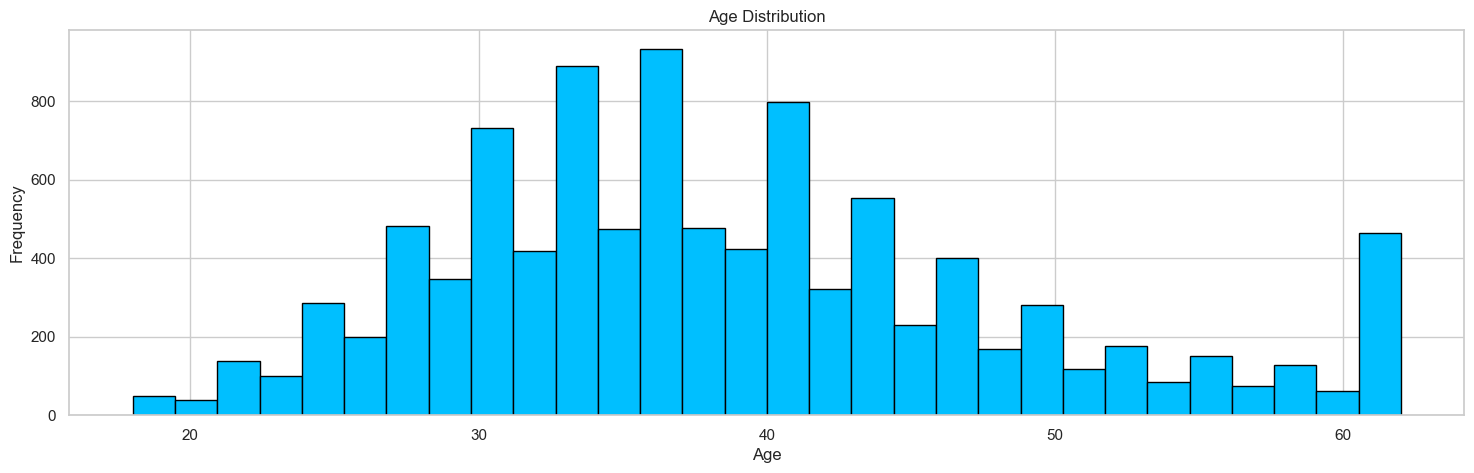

In [44]:
# Age Distribution
plt.figure(figsize=(18,5))
data['Age'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Majority of customers are between 30-40 years. Tailor services for this age group.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Are our customers financially stable?</h2>

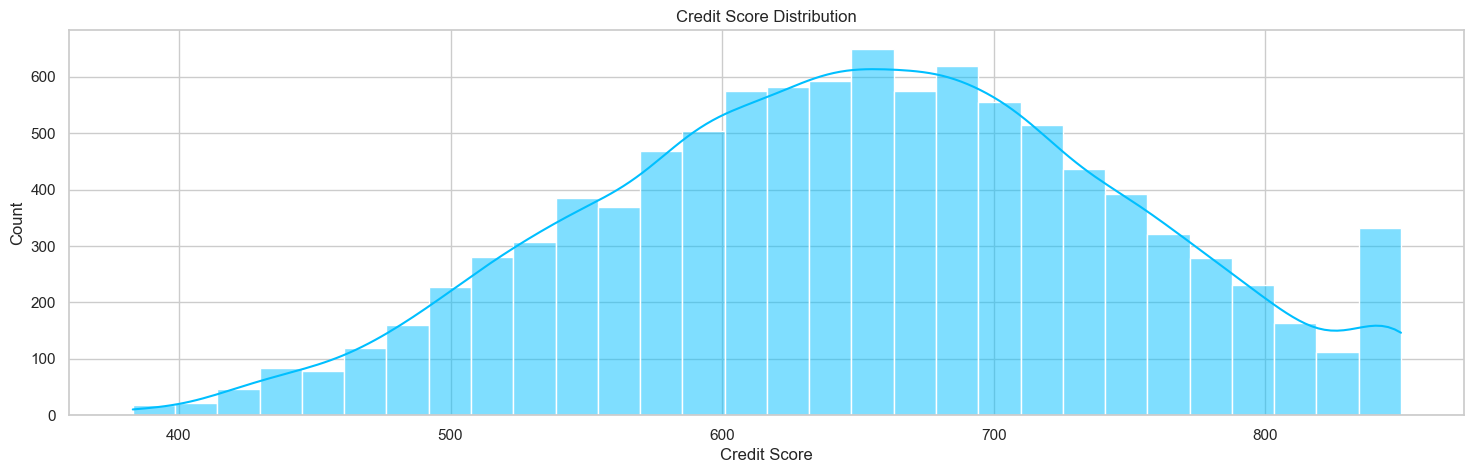

In [45]:
# Credit Score Distribution
plt.figure(figsize=(18,5))
sns.histplot(data['CreditScore'], bins=30, kde=True)
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Most customers have credit scores between 600–700, indicating moderate financial stability.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Are we attracting customers with high income?</h2>

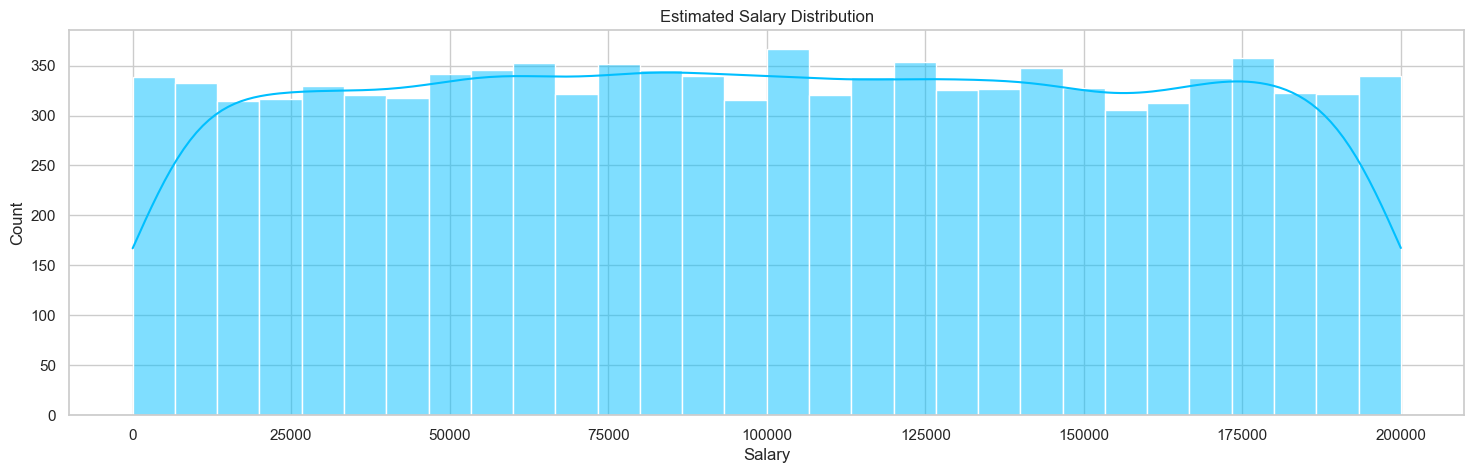

In [46]:
# Estimated Salary Distribution
plt.figure(figsize=(18,5))
sns.histplot(data['EstimatedSalary'], bins=30, kde=True)
plt.title('Estimated Salary Distribution')
plt.xlabel('Salary')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Majority earn under 100k, signaling opportunity to target higher-income brackets.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How many customers maintain high account balances?</h2>

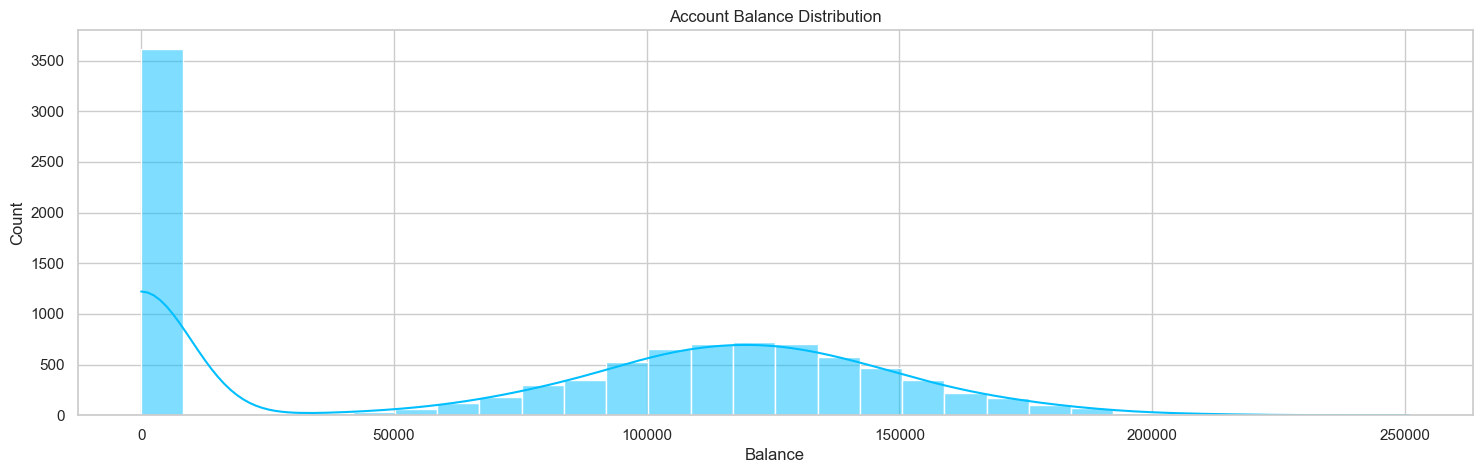

Insight: Many accounts have zero balance; engagement or product fit may be low.


In [47]:
# Balance Distribution
plt.figure(figsize=(18,5))
sns.histplot(data['Balance'], bins=30, kde=True)
plt.title('Account Balance Distribution')
plt.xlabel('Balance')
plt.show()
print("Insight: Many accounts have zero balance; engagement or product fit may be low.")

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Many accounts have zero balance; engagement or product fit may be low.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Which regions have the most customers?</h2>

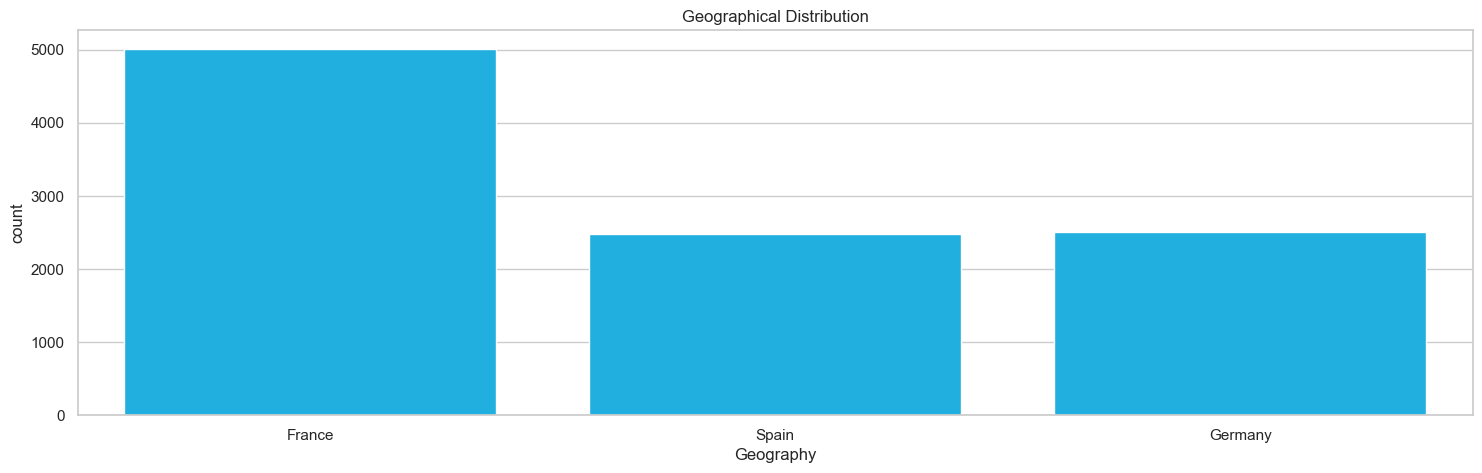

In [48]:
# Geography Distribution
plt.figure(figsize=(18,5))
sns.countplot(x='Geography', data=data)
plt.title('Geographical Distribution')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: France leads, followed by Spain and Germany. Marketing can be localized accordingly.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<span style="font-family: 'Arial', cursive; color: aqua; font-size: 30px; display: block; text-align: center;">BIVARIATE ANALYSIS</span>
<hr style="border: none; height: 3px; background-color: aqua; width: 90%; margin: 10px auto;">


<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Are certain age groups more likely to exit?</h2>

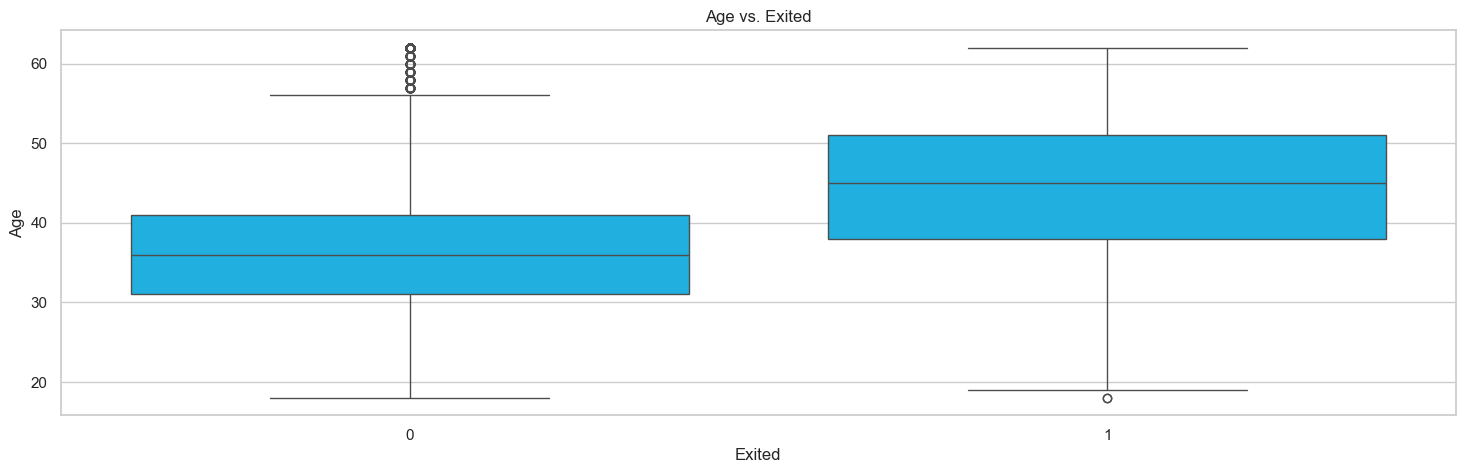

In [49]:
# Age vs. Exited
plt.figure(figsize=(18,5))
sns.boxplot(x='Exited', y='Age', data=data)
plt.title('Age vs. Exited')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Exiting customers tend to be older, suggesting loyalty programs for seniors.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Does account balance impact customer exit?</h2>

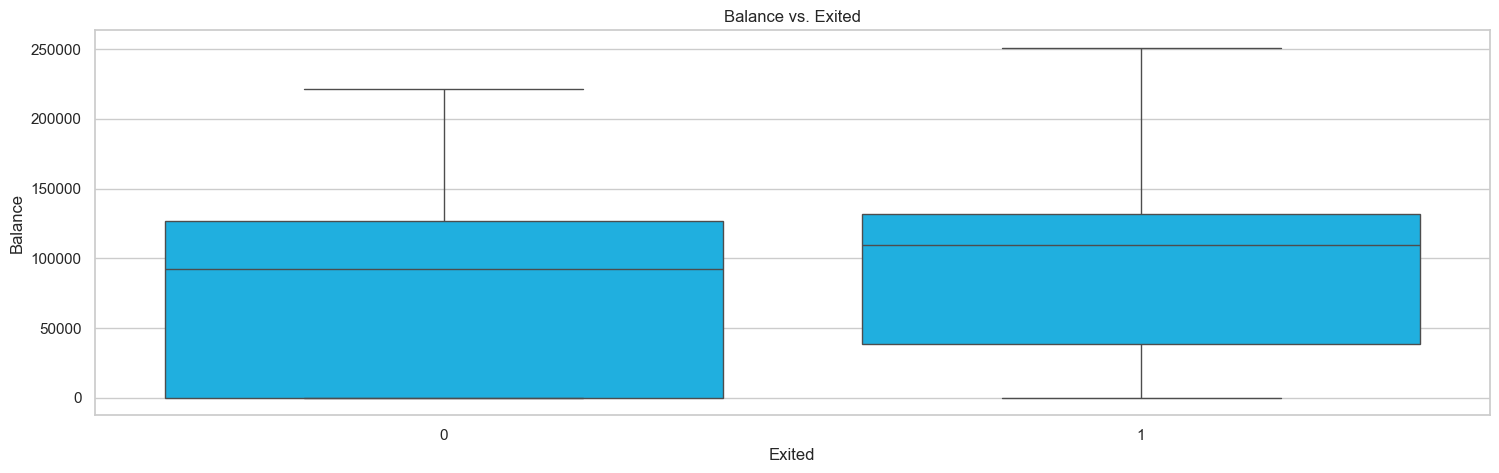

In [50]:
# Balance vs. Exited
plt.figure(figsize=(18,5))
sns.boxplot(x='Exited', y='Balance', data=data)
plt.title('Balance vs. Exited')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: High balance accounts have higher exit rates, implying dissatisfaction despite value.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Do high earners exit more?</h2>

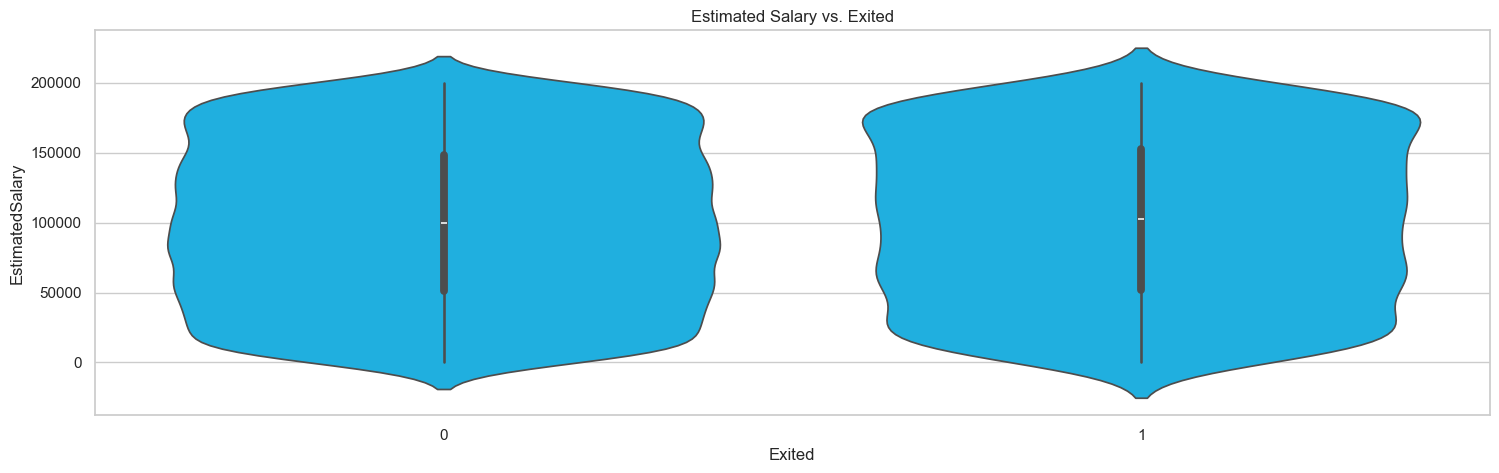

In [51]:

# EstimatedSalary vs. Exited
plt.figure(figsize=(18,5))
sns.violinplot(x='Exited', y='EstimatedSalary', data=data)
plt.title('Estimated Salary vs. Exited')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Salary alone doesn't drive churn—strategies must go beyond income tiers.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Is churn rate different across regions?</h2>

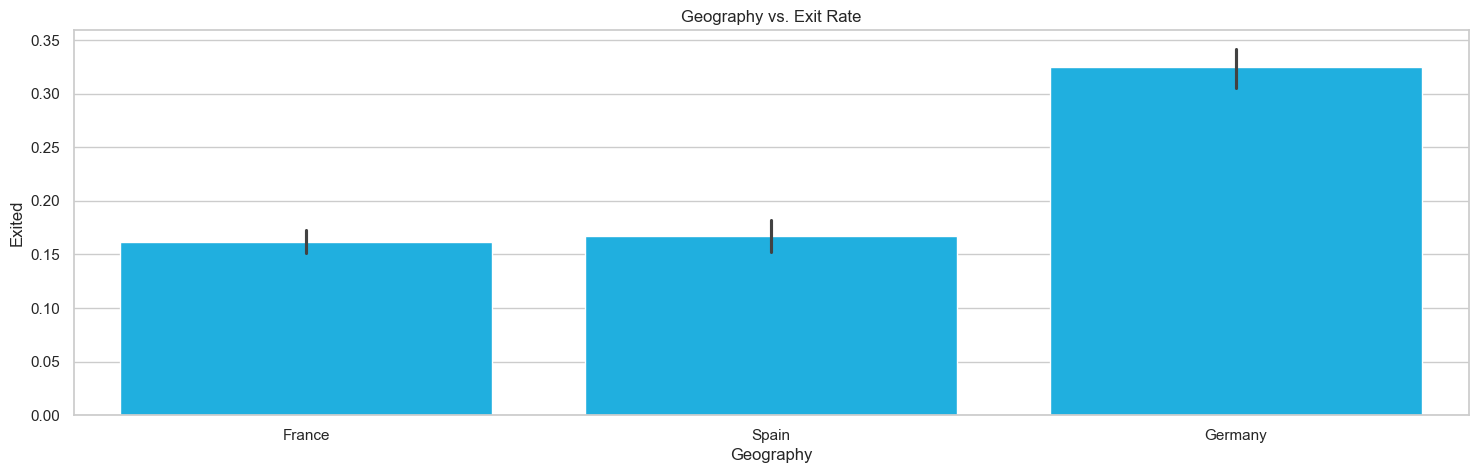

In [52]:
# Geography vs. Exited
plt.figure(figsize=(18,5))
sns.barplot(x='Geography', y='Exited', data=data)
plt.title('Geography vs. Exit Rate')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Germany shows higher churn. Localized improvements are needed.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Are men or women more likely to churn?</h2>

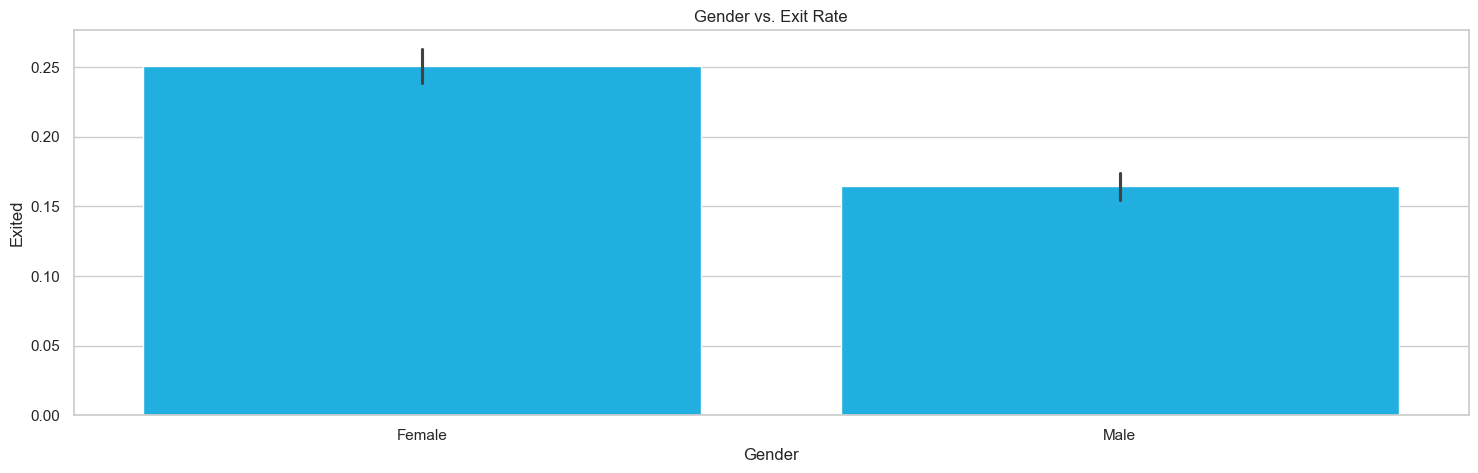

In [53]:
# Gender vs. Exited
plt.figure(figsize=(18,5))
sns.barplot(x='Gender', y='Exited', data=data)
plt.title('Gender vs. Exit Rate')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Female churn is slightly higher; gender-targeted outreach can help.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does Age relate to Credit Score, and does it affect exit behavior?</h2>

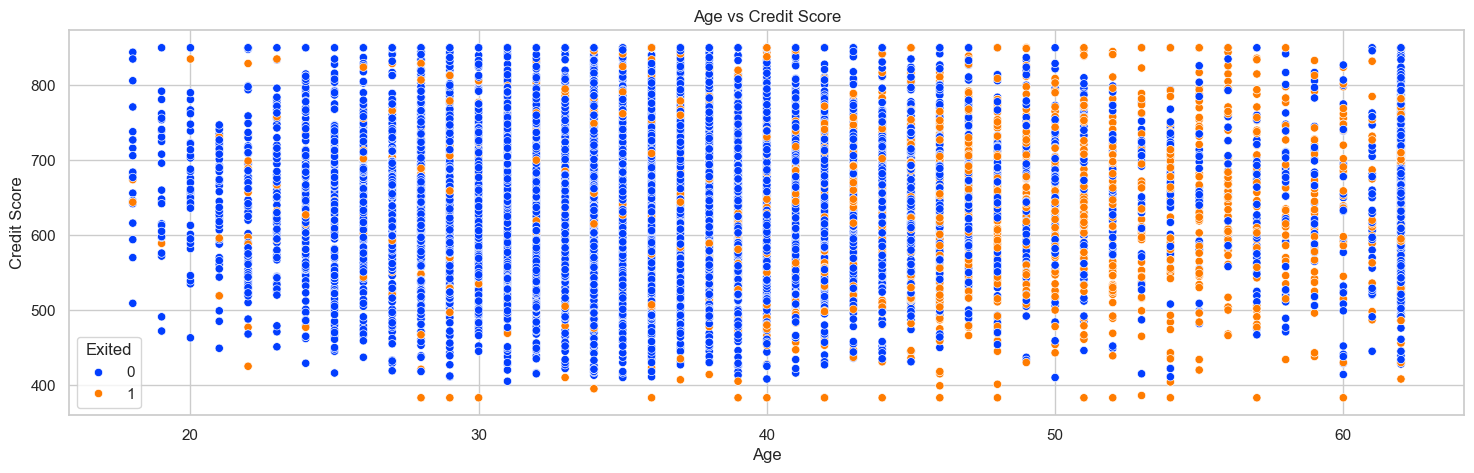

In [54]:
plt.figure(figsize=(18,5))
sns.scatterplot(x='Age', y='CreditScore', data=data, hue='Exited', palette='bright')
plt.title('Age vs Credit Score')
plt.xlabel('Age')
plt.ylabel('Credit Score')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Younger customers tend to have lower credit scores, but they don't show a strong correlation with exit behavior.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does the number of products impact account balances?</h2>

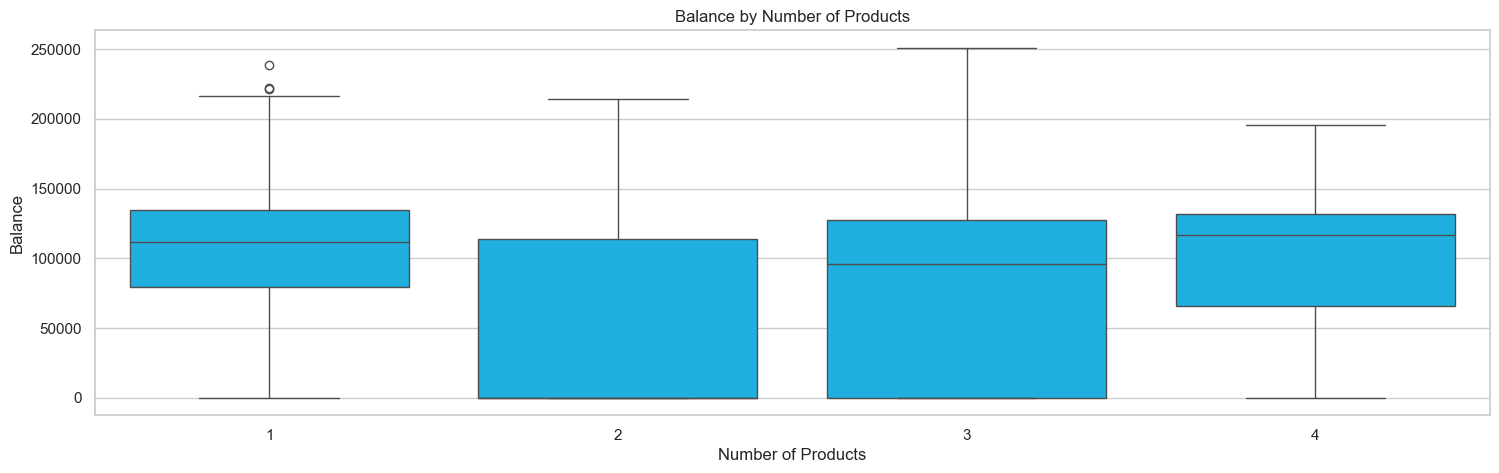

In [55]:
plt.figure(figsize=(18,5))
sns.boxplot(x='NumOfProducts', y='Balance', data=data)
plt.title('Balance by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Balance')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Customers with more products tend to have higher balances, but they also show more variability in account balance.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Are there differences in exit rates between men and women?</h2>

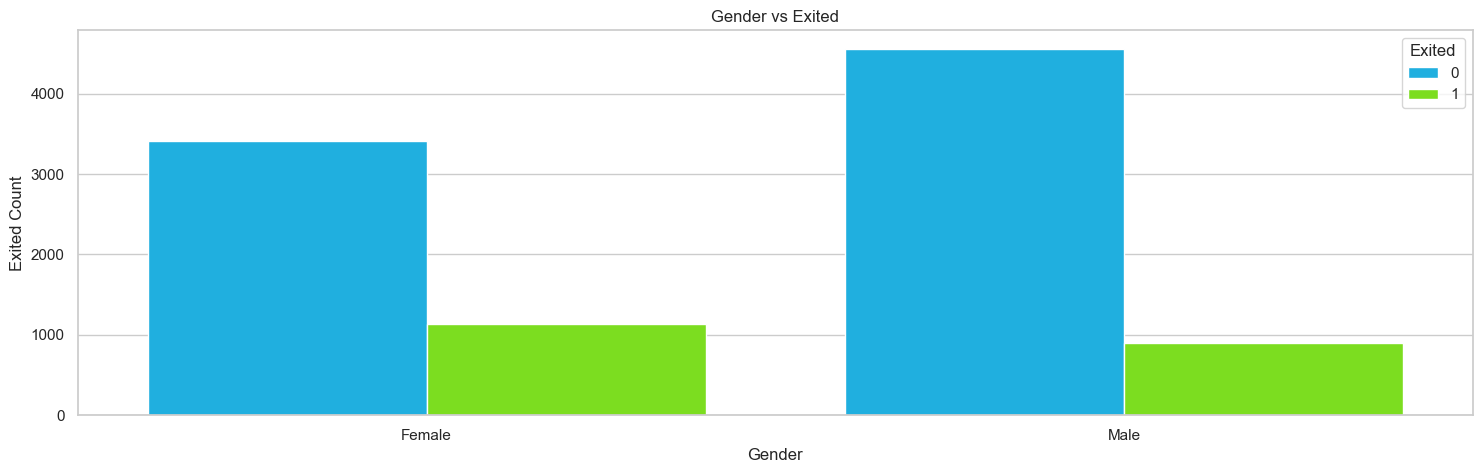

In [56]:
plt.figure(figsize=(18,5))
sns.countplot(x='Gender', hue='Exited', data=data)
plt.title('Gender vs Exited')
plt.xlabel('Gender')
plt.ylabel('Exited Count')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Both genders show a similar level of exit, but women tend to churn slightly more.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does Tenure relate to Credit Score?</h2>

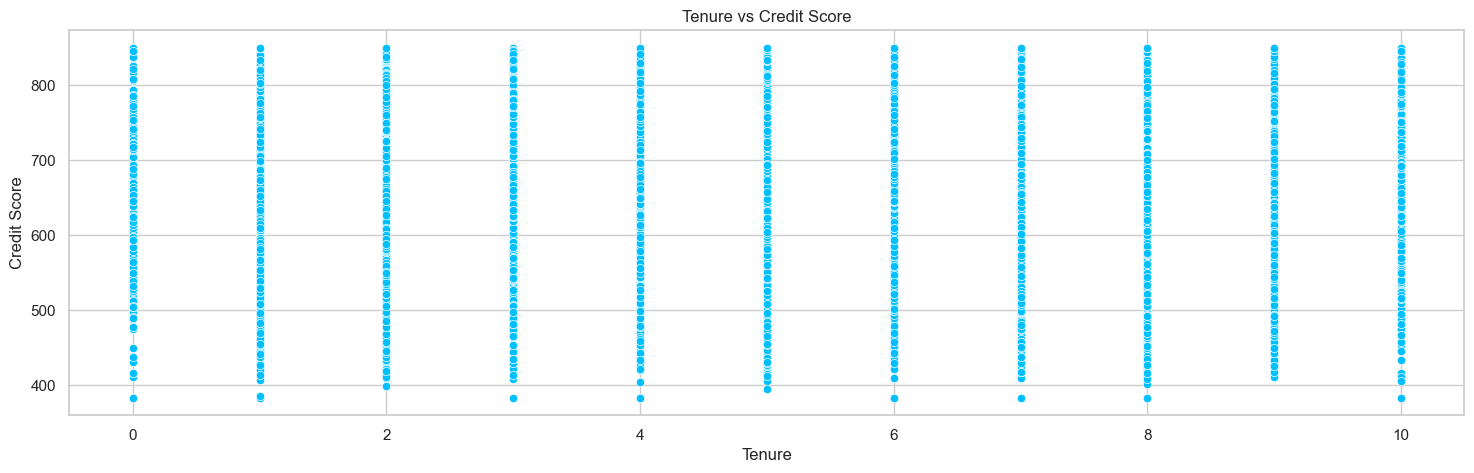

In [57]:
plt.figure(figsize=(18,5))
sns.scatterplot(x='Tenure', y='CreditScore', data=data)
plt.title('Tenure vs Credit Score')
plt.xlabel('Tenure')
plt.ylabel('Credit Score')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">
Insight: Credit scores appear fairly consistent across all tenure levels, suggesting tenure does not significantly influence creditworthiness in this dataset.
</h7>


<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Is there any noticeable relationship between Age and Estimated Salary?</h2>

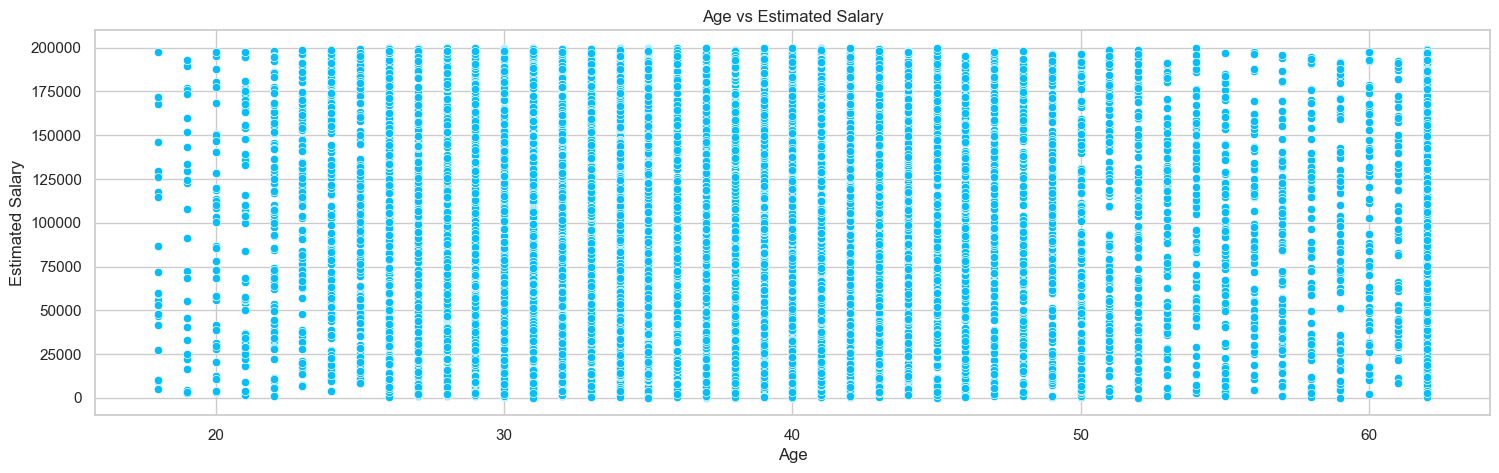

In [58]:
plt.figure(figsize=(18,5))
sns.scatterplot(x='Age', y='EstimatedSalary', data=data)
plt.title('Age vs Estimated Salary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: There seems to be no strong correlation between age and estimated salary, but younger people are more likely to have lower salaries.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<span style="font-family: 'Arial', cursive; color: aqua; font-size: 30px; display: block; text-align: center;">MULTIVARIATE ANALYSIS</span>

<hr style="border: none; height: 3px; background-color: aqua; width: 100%; margin: 10px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How do age and balance together influence exit?</h2>

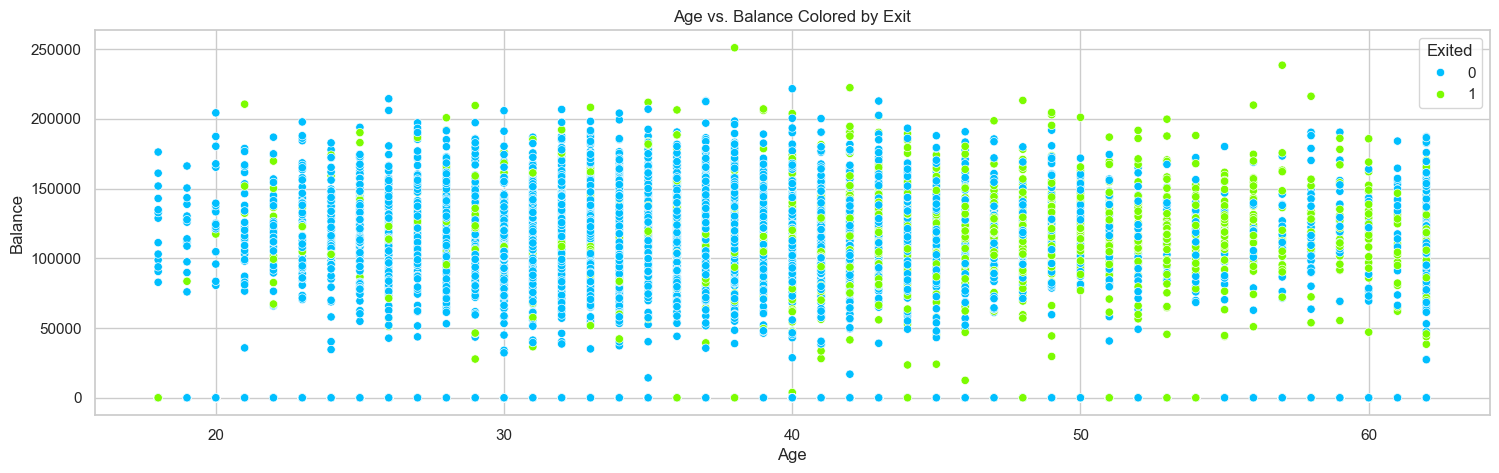

In [59]:
# Age vs. Balance vs. Exited
plt.figure(figsize=(18,5))
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=data)
plt.title('Age vs. Balance Colored by Exit')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Older customers with higher balances tend to churn more.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How do credit and salary together relate to churn?</h2>

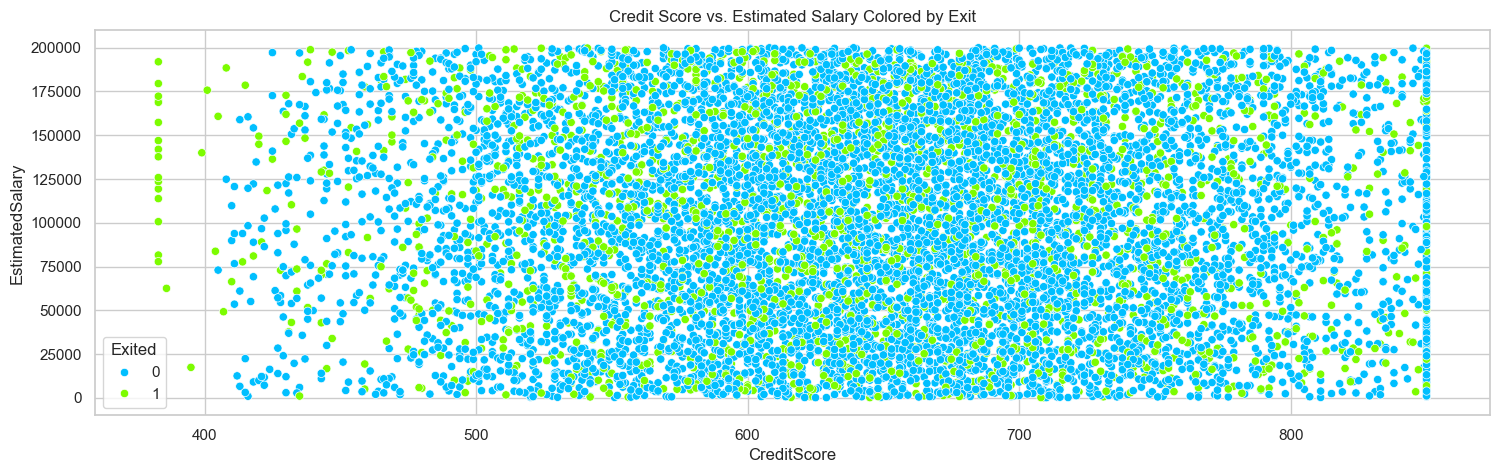

In [60]:
# CreditScore vs. EstimatedSalary by Exited
plt.figure(figsize=(18,5))
sns.scatterplot(x='CreditScore', y='EstimatedSalary', hue='Exited', data=data)
plt.title('Credit Score vs. Estimated Salary Colored by Exit')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Churn is dispersed, not focused on low-credit or low-salary groups.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Does geography and gender combination affect churn?</h2>

<Figure size 1800x500 with 0 Axes>

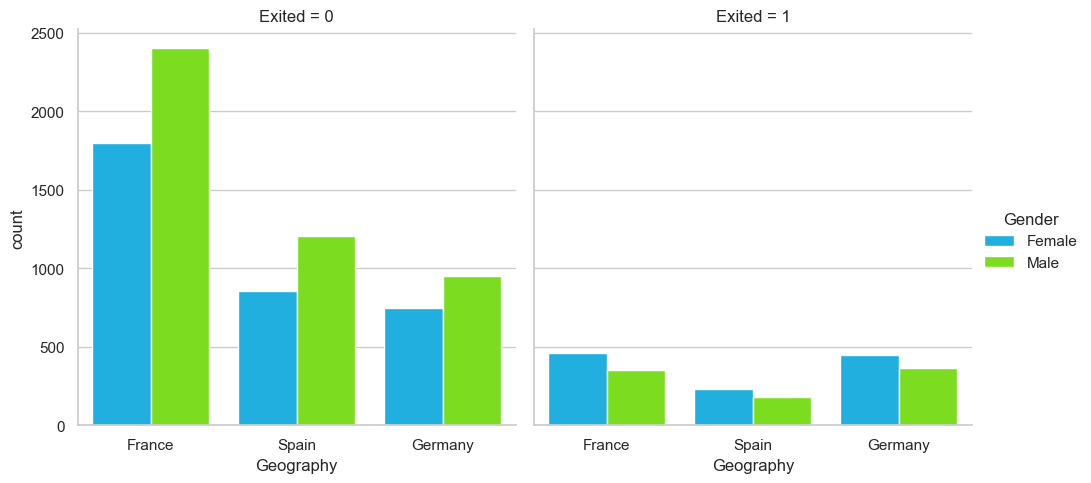

In [61]:
# Geography, Gender, and Exit
plt.figure(figsize=(18,5))
sns.catplot(x='Geography', hue='Gender', col='Exited', kind='count', data=data)
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight:France and German female customers show higher exits. Focus efforts here.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Does product engagement and credit card usage affect retention?</h2>

<Figure size 1800x500 with 0 Axes>

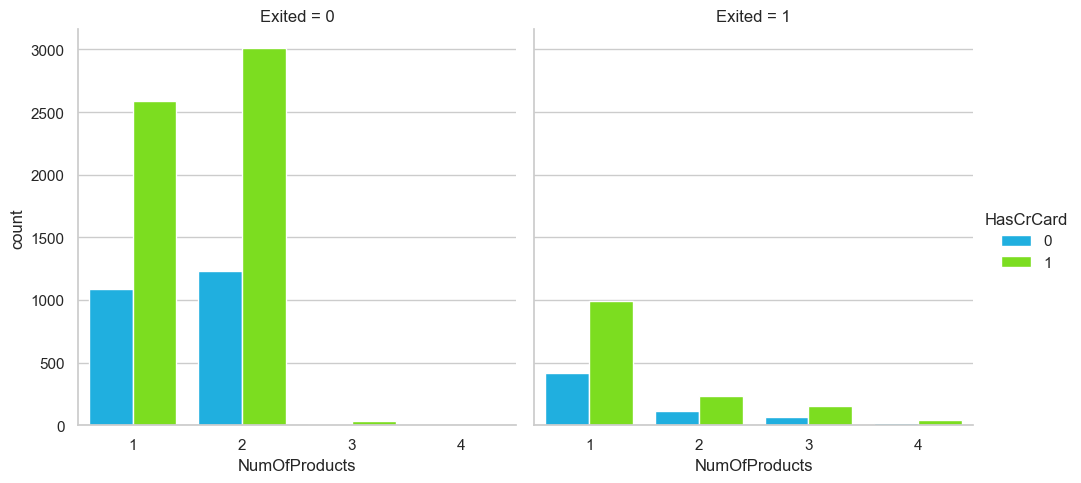

In [62]:
# NumOfProducts vs. HasCrCard vs. Exited
plt.figure(figsize=(18,5))
sns.catplot(x='NumOfProducts', hue='HasCrCard', col='Exited', kind='count', data=data)
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Customers with 3+ products are more likely to churn, regardless of card ownership.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Does age modify churn among inactive members?</h2>

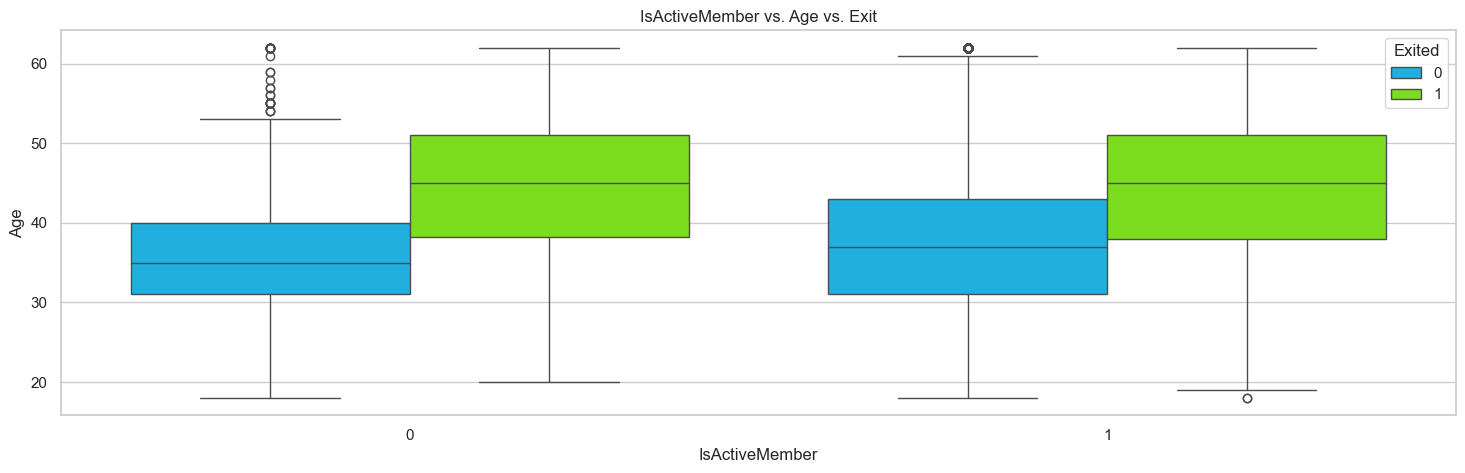

In [63]:
# IsActiveMember vs. Age vs. Exited
plt.figure(figsize=(18,5))
sns.boxplot(x='IsActiveMember', y='Age', hue='Exited', data=data)
plt.title('IsActiveMember vs. Age vs. Exit')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Inactive older members churn more. Activation strategies needed.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">What are the relationships between Age, Credit Score, and Estimated Salary?</h2>

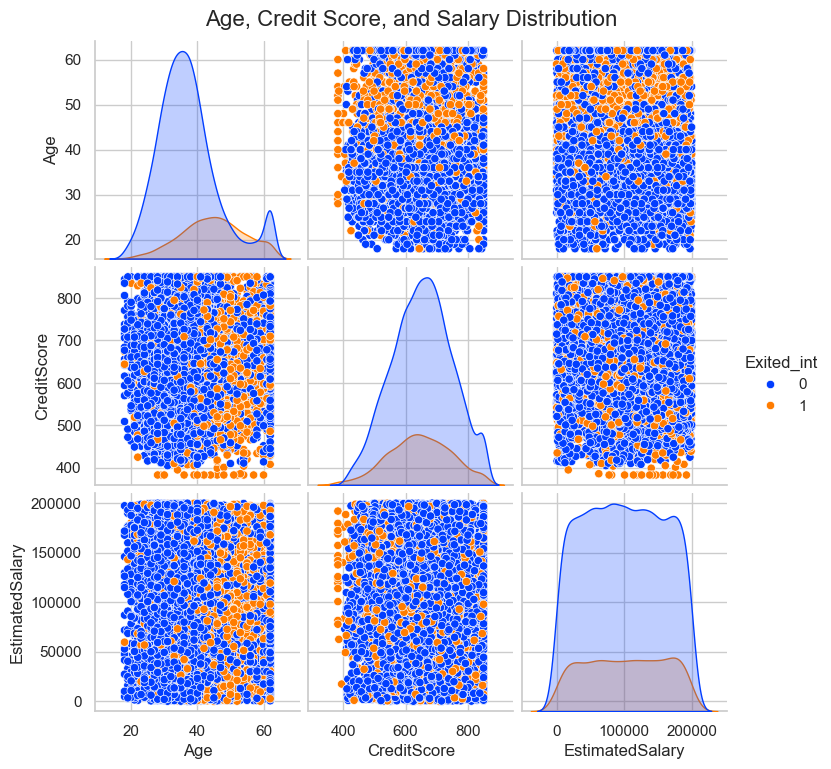

In [64]:

sns.pairplot(data.assign(Exited_int=data['Exited'].astype(int))[
    ['Age', 'CreditScore', 'EstimatedSalary', 'Exited_int']],
    hue='Exited_int',
    palette='bright'
)
plt.suptitle('Age, Credit Score, and Salary Distribution', fontsize=16, y=1.02)
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: There is a slight trend of younger individuals having lower credit scores and estimated salaries, but no strong pattern of churn.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">What is the correlation between Balance, Number of Products, and Exited status?</h2>

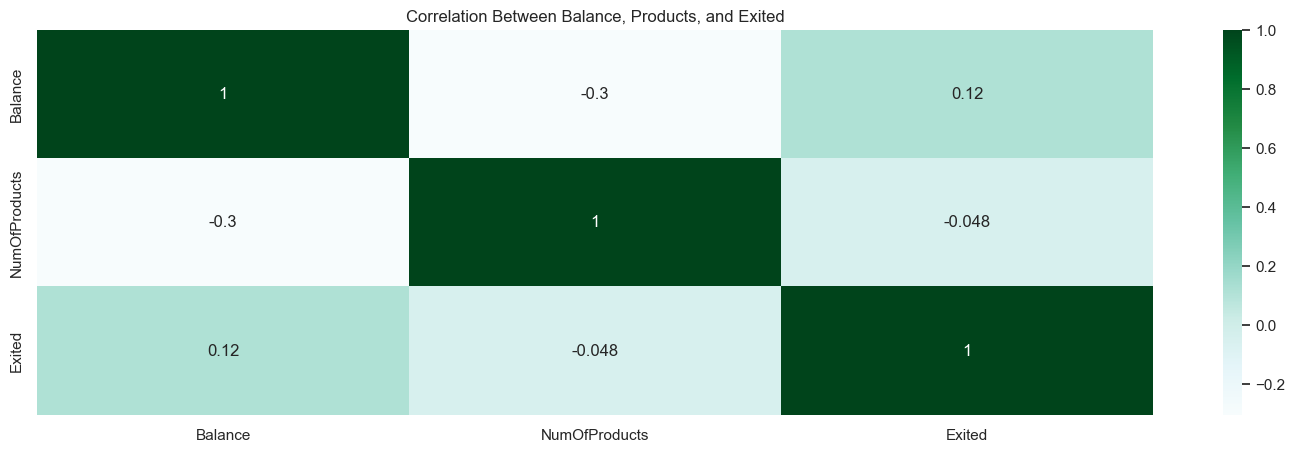

In [65]:
plt.figure(figsize=(18,5))
sns.heatmap(data[['Balance', 'NumOfProducts', 'Exited']].corr(), annot=True, cmap='BuGn')
plt.title('Correlation Between Balance, Products, and Exited')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Balance and Number of Products are negatively correlated.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How do Age and Tenure affect Exited status?</h2>

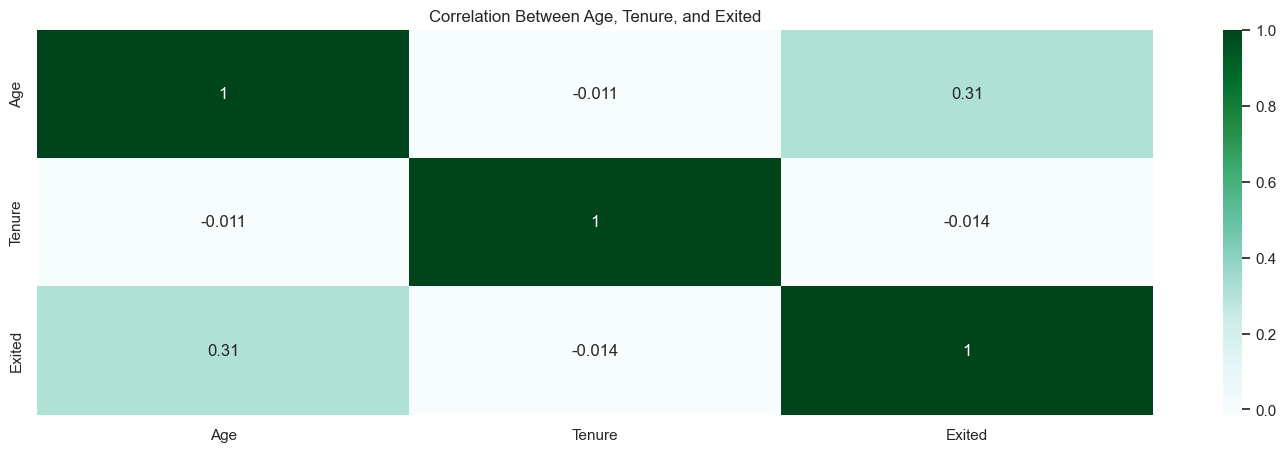

In [66]:
plt.figure(figsize=(18,5))
sns.heatmap(data[['Age', 'Tenure', 'Exited']].corr(), annot=True, cmap='BuGn')
plt.title('Correlation Between Age, Tenure, and Exited')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Tenure is negatively correlated with Exited status and Age is positively correlated with Exited, indicating that long-tenured customers are less likely to churn and Older are more likely to churn.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Does gender and age affect the exit rate?</h2>

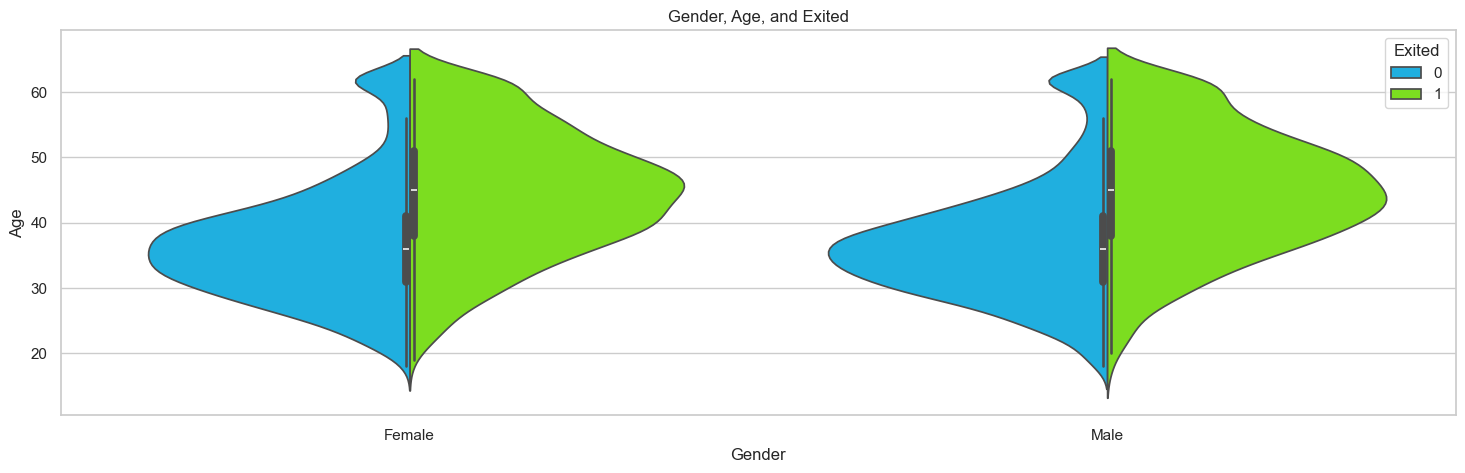

In [67]:
plt.figure(figsize=(18,5))
sns.violinplot(x='Gender', y='Age', hue='Exited', split=True, data=data)
plt.title('Gender, Age, and Exited')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Female customers tend to be younger and show slightly higher exit rates. The relationship between gender and exit behavior is nuanced.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How do the number of products, balance, and salary impact exit probability?</h2>

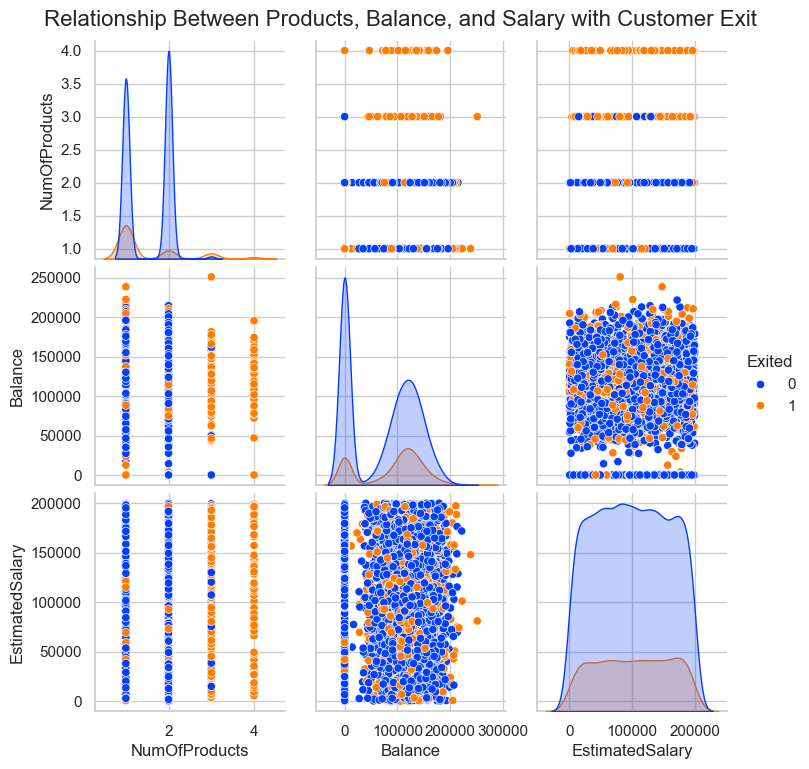

In [68]:

sns.pairplot(
    data[['NumOfProducts', 'Balance', 'EstimatedSalary', 'Exited']],
    hue='Exited',
    palette='bright',
)
plt.suptitle('Relationship Between Products, Balance, and Salary with Customer Exit', fontsize=16, y=1.02)
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Customers with a higher number of products have higher exit probabilities, but balance and salary alone do not drive exit behaviors.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does Tenure, Products, and Exit Probability interact?</h2>

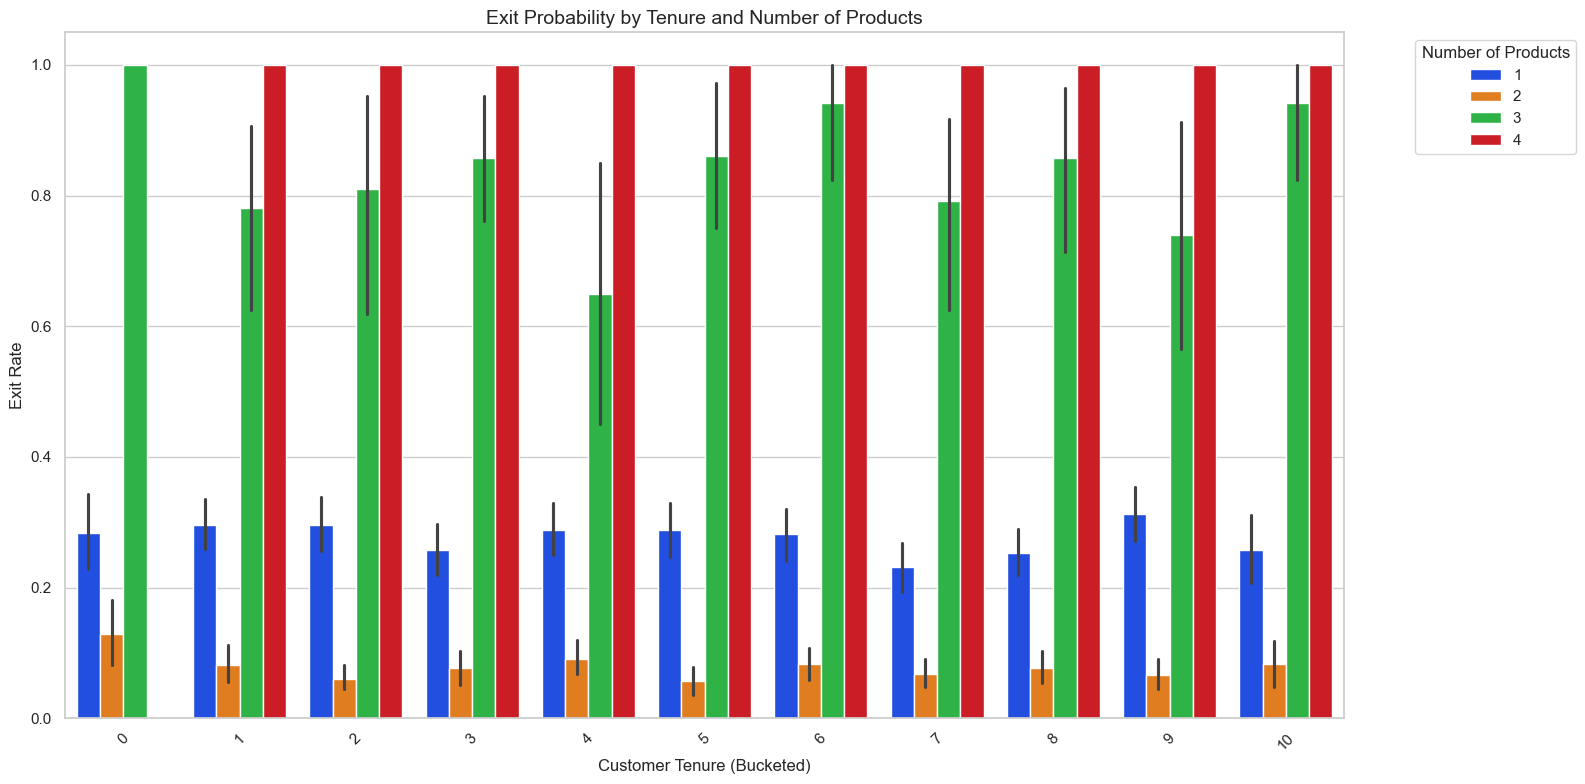

In [69]:
plt.figure(figsize=(16,8))
sns.barplot(x='Tenure', y='Exited', hue='NumOfProducts', data=data, palette='bright')

plt.title('Exit Probability by Tenure and Number of Products', fontsize=14)
plt.xlabel('Customer Tenure (Bucketed)', fontsize=12)
plt.ylabel('Exit Rate', fontsize=12)
plt.legend(title='Number of Products', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: New customers with fewer products show higher exit rates. Long-term engagement and multiple products are key to retaining customers.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How do Age, Credit Score, and Balance together influence Exited?</h2>

In [70]:
import plotly.express as px

fig = px.scatter_3d(
    data_frame=data,
    x='Age',
    y='CreditScore',
    z='Balance',
    color='Exited',
    color_continuous_scale='BuRd',
    title='3D Plot of Age, Credit Score, and Balance',
    labels={
        'Age': 'Customer Age',
        'CreditScore': 'Credit Score',
        'Balance': 'Account Balance',
        'Exited': 'Churn Status'
    }
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(
    xaxis_title='Age',
    yaxis_title='Credit Score',
    zaxis_title='Balance'
))
fig.show()


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">
Insight: Churn patterns are dispersed, but slight trends suggest customers with lower balances and credit scores may be more prone to exit. Age alone doesn't clearly differentiate churn behavior.
</h7>


<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<span style="font-family: 'Arial', cursive; color: aqua; font-size: 30px; display: block; text-align: center;"> KPI-focused Visualizations</span>


<hr style="border: none; height: 3px; background-color: aqua; width: 100%; margin: 10px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Overall Churn Rate</h2>

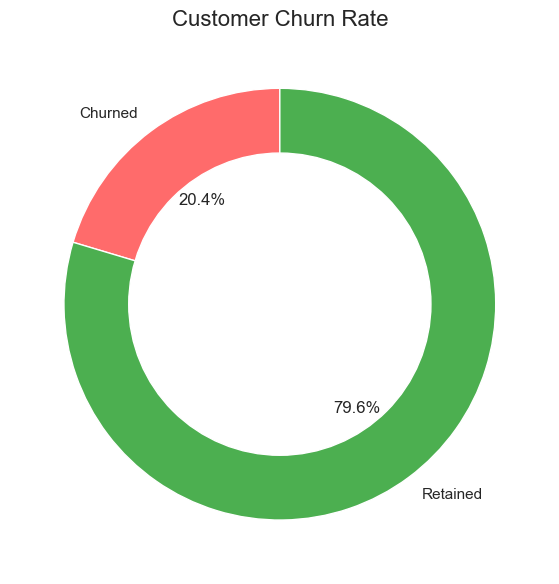

Churn Rate: 20.37%


In [71]:
# Calculate churn and retention rates
churn_rate = data['Exited'].mean()
retention_rate = 1 - churn_rate

# Plot
labels = ['Churned', 'Retained']
sizes = [churn_rate, retention_rate]
colors = ['#FF6B6B', '#4CAF50']

fig, ax = plt.subplots(figsize=(19,6))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                  startangle=90, colors=colors, wedgeprops=dict(width=0.4))

# Add center circle for donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Title and style
plt.title('Customer Churn Rate', fontsize=16)
plt.tight_layout()
plt.show()


print(f"Churn Rate: {churn_rate * 100:.2f}%")

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">
Insight: This chart shows the proportion of customers who exited. A lower churn rate indicates higher retention success.</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Churn by Geography</h2>


KPI: Churn Rate by Geography
Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: object


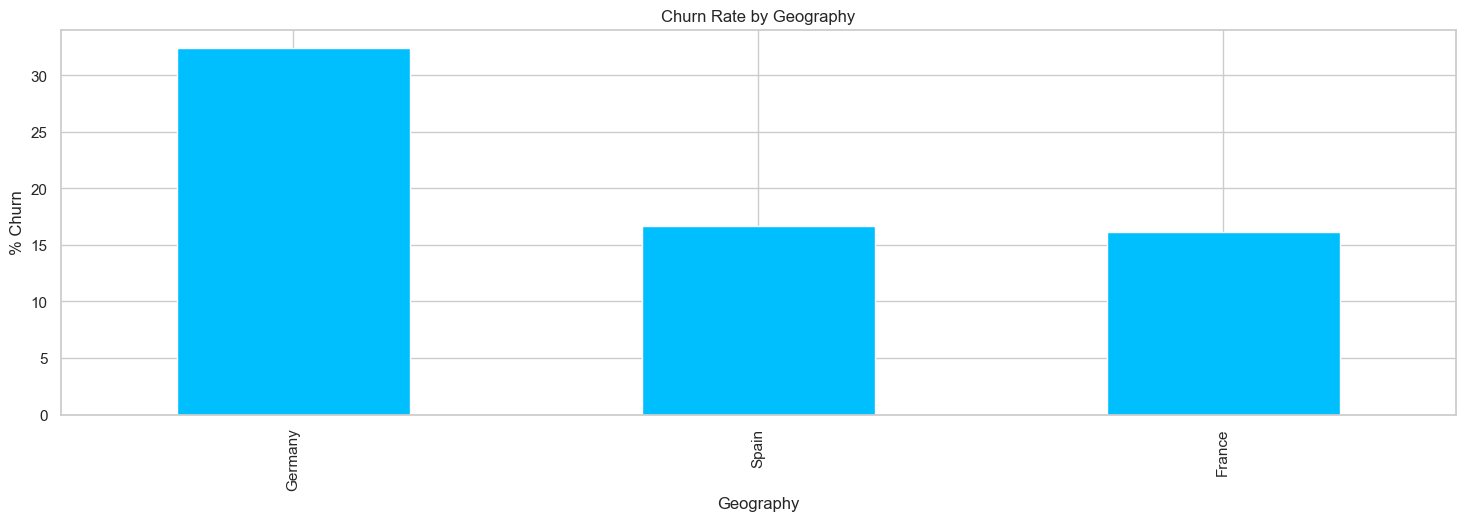

In [72]:
plt.figure(figsize=(18,5))
print("\nKPI: Churn Rate by Geography")
geo_churn = data.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
print(geo_churn)
geo_churn.plot(kind='bar', title='Churn Rate by Geography')
plt.ylabel('% Churn')
plt.show()


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Germany has the highest churn. Focused campaigns needed there.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Churn by Tenure Bucket</h2>


KPI: Churn by Customer Tenure
TenureBucket
New      21.153846
Mid       20.76412
Loyal    19.670672
Name: Exited, dtype: object


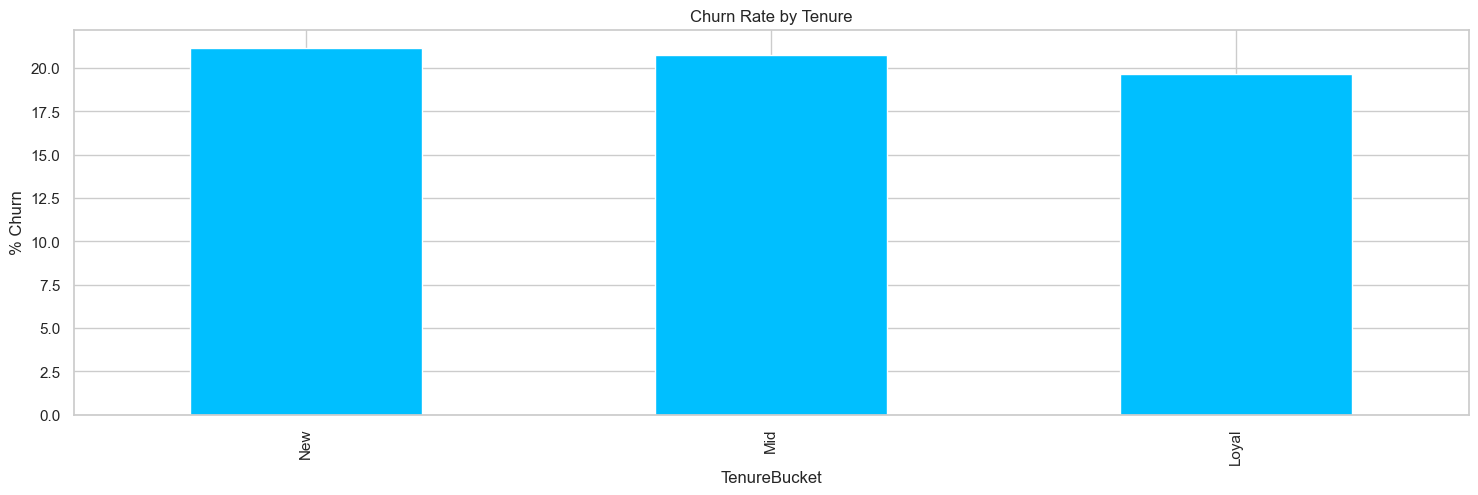

In [73]:
plt.figure(figsize=(18,5))
print("\nKPI: Churn by Customer Tenure")
data['TenureBucket'] = pd.cut(data['Tenure'], bins=[-1,2,5,10], labels=['New','Mid','Loyal'])
tenure_churn = data.groupby('TenureBucket')['Exited'].mean() * 100
print(tenure_churn)
tenure_churn.plot(kind='bar', title='Churn Rate by Tenure')
plt.ylabel('% Churn')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: New customers churn more. Improve onboarding experience.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Revenue at Risk by Churned Customers</h2>

<Figure size 1800x500 with 0 Axes>

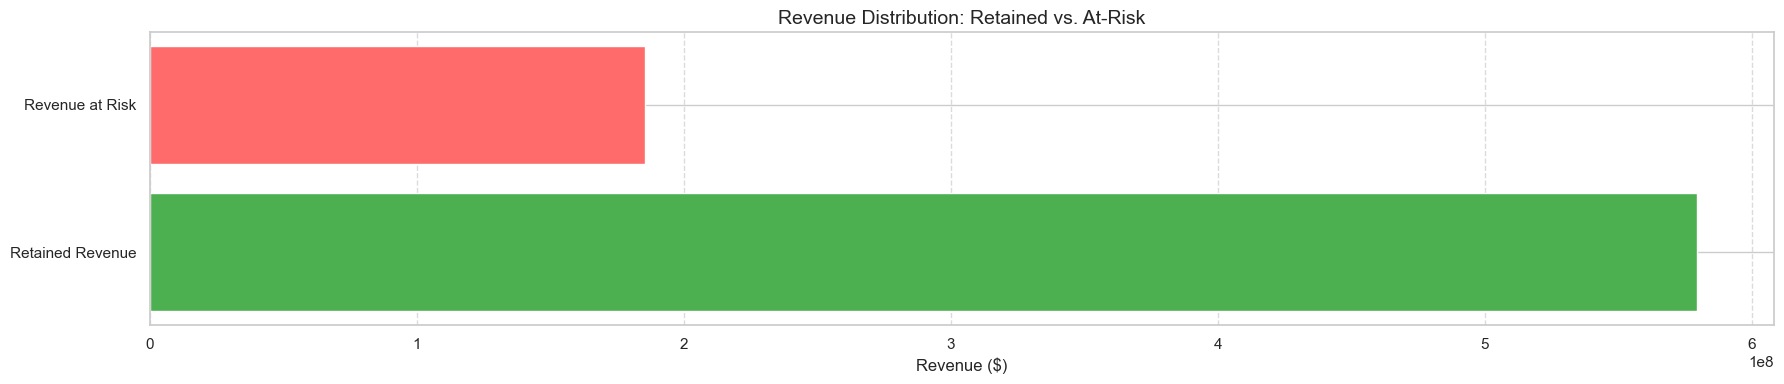

Revenue at Risk: $185,588,094.63


In [74]:
# Total and at-risk revenue
plt.figure(figsize=(18,5))

total_balance = data['Balance'].sum()
revenue_at_risk = data[data['Exited'] == 1]['Balance'].sum()
retained_revenue = total_balance - revenue_at_risk

# Plot values
labels = ['Retained Revenue', 'Revenue at Risk']
values = [retained_revenue, revenue_at_risk]
colors = ['#4CAF50', '#FF6B6B']


plt.figure(figsize=(18, 4))
plt.barh(labels, values, color=colors)
plt.xlabel('Revenue ($)', fontsize=12)
plt.title('Revenue Distribution: Retained vs. At-Risk', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Revenue at Risk: ${revenue_at_risk:,.2f}")

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">
Insight: A significant portion of revenue is at stake due to churn. Focus on high-balance customers for retention.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">Product Penetration Rate (Customers with >1 product)</h2>

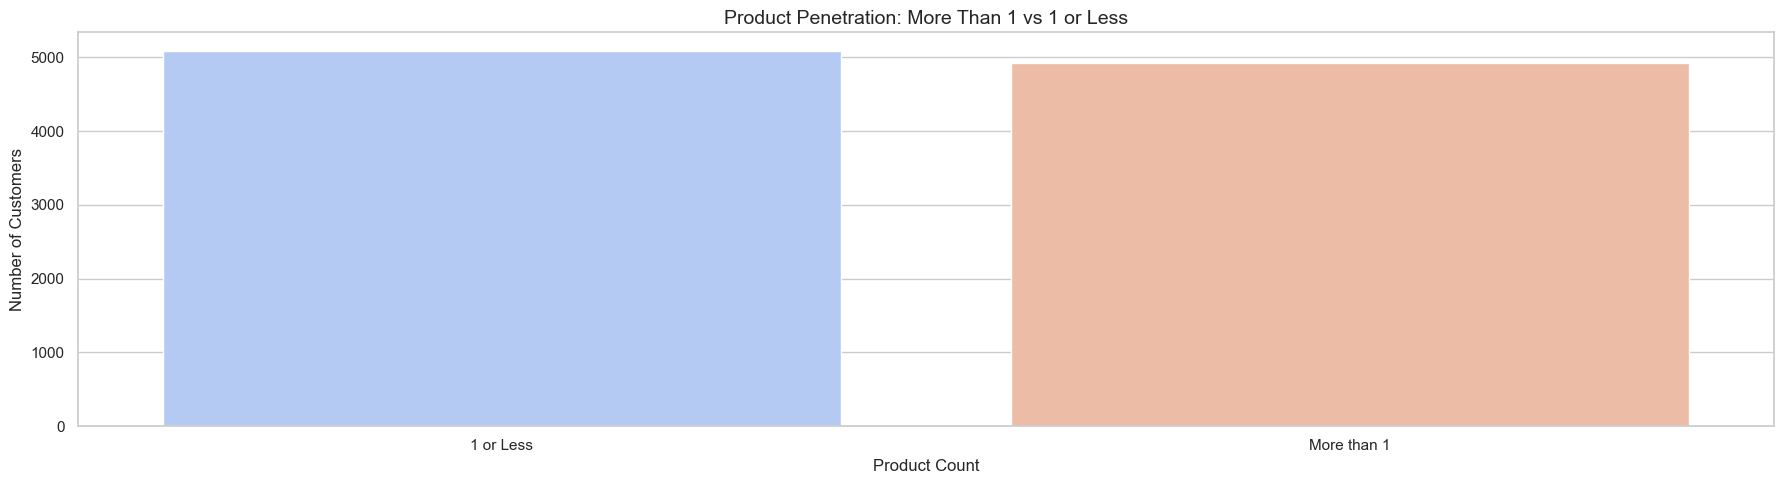

In [75]:
# Calculate product penetration
penetration_data = data['NumOfProducts'].apply(lambda x: 'More than 1' if x > 1 else '1 or Less')
penetration_counts = penetration_data.value_counts()

# Plot
plt.figure(figsize=(18,5))
sns.barplot(x=penetration_counts.index, y=penetration_counts.values, palette='coolwarm')
plt.title('Product Penetration: More Than 1 vs 1 or Less', fontsize=14)
plt.xlabel('Product Count', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Low penetration suggests an opportunity for upselling additional products to increase customer value.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">What is the churn rate by Age group?</h2>

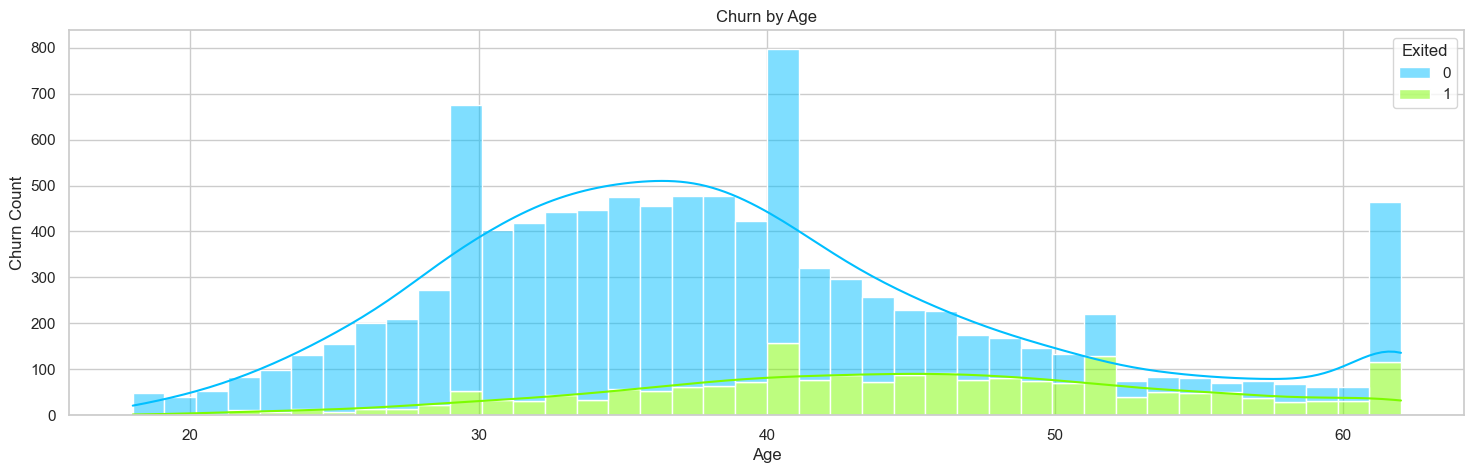

In [76]:
plt.figure(figsize=(18,5))
sns.histplot(data=data, x='Age', hue='Exited', multiple='stack', kde=True)
plt.title('Churn by Age')
plt.xlabel('Age')
plt.ylabel('Churn Count')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Churn rates are higher among mid to old age groups. Targeted retention efforts for these groups are needed.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does account balance impact exit rates?</h2>

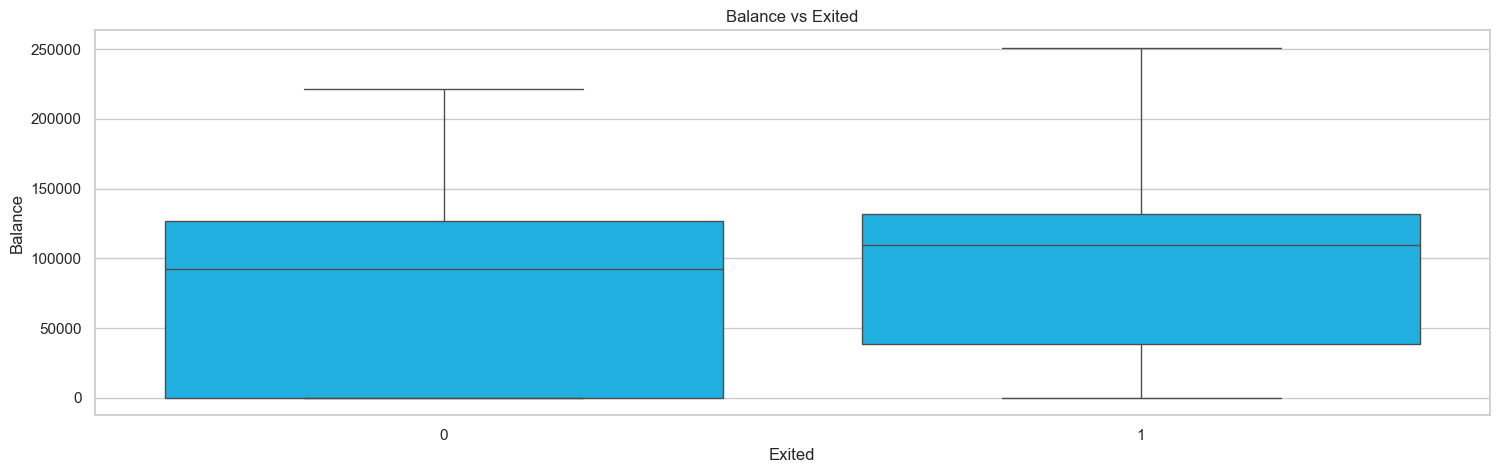

In [77]:
plt.figure(figsize=(18,5))
sns.boxplot(x='Exited', y='Balance', data=data)
plt.title('Balance vs Exited')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Higher balances tend to have lower exit rates, but some high balance customers still exit, indicating dissatisfaction.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">How does Age and Credit Score affect churn probability?</h2>

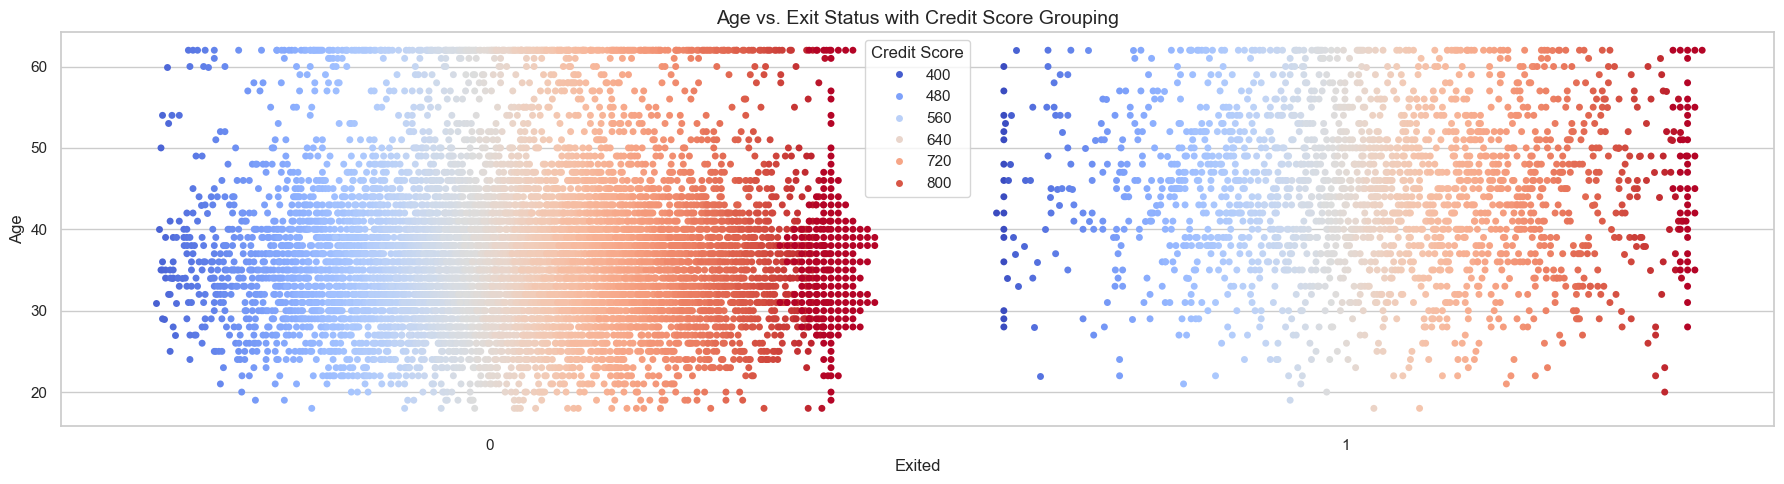

In [78]:

plt.figure(figsize=(18,5))
sns.swarmplot(x='Exited', y='Age', hue='CreditScore', data=data, palette='coolwarm', dodge=True)
plt.title('Age vs. Exit Status with Credit Score Grouping', fontsize=14)
plt.xlabel('Exited')
plt.ylabel('Age')
plt.legend(title='Credit Score')
plt.tight_layout()
plt.show()


<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight:Customers who exited (Exited = 1) tend to be older and have higher credit scores compared to those who stayed, suggesting age and credit score may influence churn behavior.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">



<h2 style="font-family: 'Arial', sans-serif; color:rgb(180, 88, 238); font-size: 30px; text-align: left; font-weight: 400;">What is the exit rate based on the number of products owned?</h2>

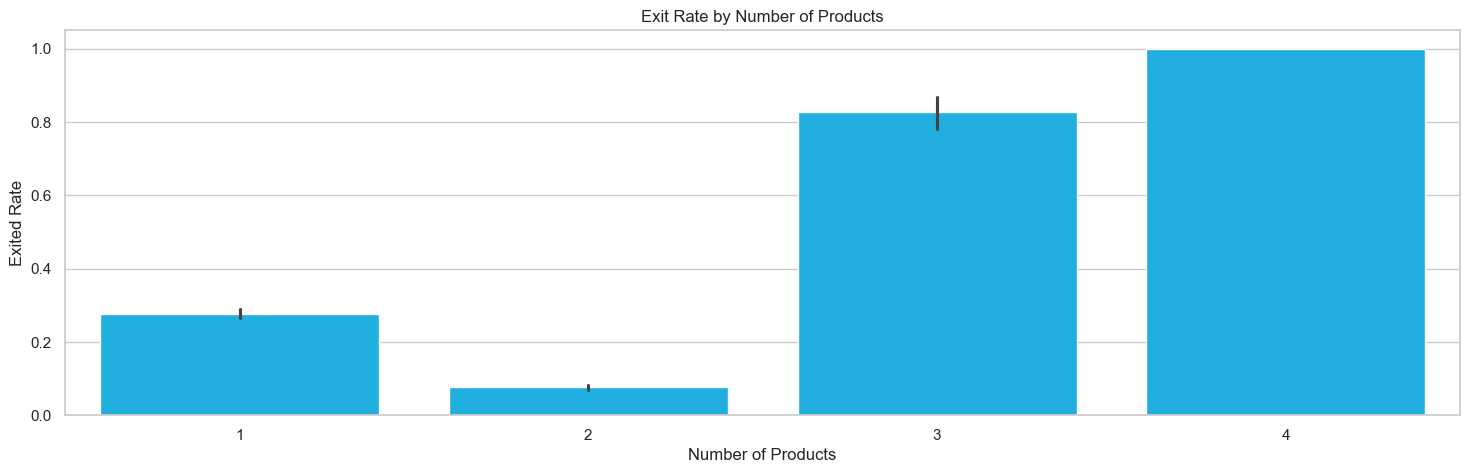

In [79]:
plt.figure(figsize=(18,5))
sns.barplot(x='NumOfProducts', y='Exited', data=data)
plt.title('Exit Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Exited Rate')
plt.show()

<h7 style="color:#39FF14;font-style:italic; font-family:Georgia">Insight: Customers with 3+ products tend to exit more often, indicating an opportunity to upsell products to improve retention.
</h7>

<hr style="border: none; height: 2px; background-color: yellow; width: 100%; margin: 2px auto;">

--------

<h1 style="font-family: 'Georgia', serif; color: orange; font-size: 40px; text-align: center; font-weight: 500;">Feature Engineering</h1>


We use a Pipeline to streamline the preprocessing steps, including Label Encoding, Scaling, and applying a ColumnTransformer to handle numerical and categorical features separately. Since the dataset contains no missing values, we do not include any imputation step. If the dataset is imbalanced, SMOTE (Synthetic Minority Over-sampling Technique) can be applied after preprocessing and before model training to balance the target classes.

In [80]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,TenureBucket
0,619.0,France,Female,42.0,2,0.00,1,1,1,101348.88,1,New
1,608.0,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0,New
2,502.0,France,Female,42.0,8,159660.80,3,1,0,113931.57,1,Loyal
3,699.0,France,Female,39.0,1,0.00,2,0,0,93826.63,0,New
4,850.0,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0,New


In [81]:
# Typecasting the Target Feature:
data["Exited"] = data["Exited"].astype(int)

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Segregating Features (X) and Target (y)</h2>

In [82]:
# Segregating the Input Features and the Target Feature:
X = data.drop(columns=['Exited'],axis=1)
y = data['Exited']

In [83]:
# Columns Groups:
categorical_cols_for_pipeline = ['Geography', 'Gender']
numerical_cols_for_pipeline = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
to_typecast_object_to_num_cols_for_pipeline =  ['NumOfProducts', 'HasCrCard', 'IsActiveMember']

In [84]:
def convert_object_to_int(x):
    return x.astype(int)


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Building the Preprocessor (Pipeline + ColumnTransformer)</h2>

In [85]:
# Pipelines for each Type:

# Numeric Pipeline:

numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False))  # Change here to avoid centering sparse matrices
        ]
)

# Categorical Pipeline:
categorical_pipeline = Pipeline(
    steps=[
        ("ohe",OneHotEncoder(handle_unknown='ignore')),
        ("scaler",StandardScaler(with_mean=False))
    ]
)


object_to_num_pipeline = Pipeline(
    steps=[
        ("type_casting", FunctionTransformer(convert_object_to_int,validate=False)),
        ("scaler",StandardScaler(with_mean=False))
    ]
)


In [86]:
# Combining all the Pipeline Components using the ColumnTransformer:

preprocessor = ColumnTransformer(transformers=[
    ('numeric_pipeline',numeric_pipeline,numerical_cols_for_pipeline),
    ('categorical_pipeline',categorical_pipeline,categorical_cols_for_pipeline),
    ('type_casting_pipeline',object_to_num_pipeline,to_typecast_object_to_num_cols_for_pipeline)
])

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Checking Class Imbalance in the Dataset</h2>

In [87]:
# Checking for the Imbalance in the Target Feature:

def check_imbalance(y):
    print("Checking the class distribution:")
    print(y.value_counts(normalize=True))
    
    sns.countplot(x=y)
    plt.title("Class Distribution of the Target Column : Exited")
    plt.show()
    
    ratio = y.value_counts(normalize=True).values
    is_imbalanced = ratio[0] > 0.7 or ratio[1] > 0.7

    if is_imbalanced:
        print("Yes, the data is imbalanced.")
    else:
        print("No, the data is fairly balanced.")
    
    return is_imbalanced

Checking the class distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


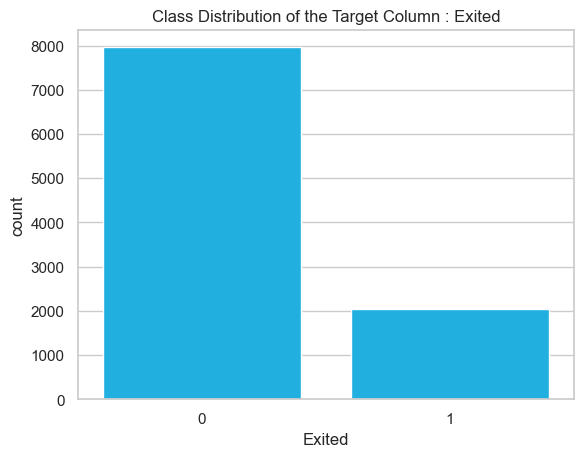

Yes, the data is imbalanced.


np.True_

In [88]:
# Returns True if there is a significant class imbalance, where one class constitutes more than 70% of the data
# and the other class is less than 30%. In such cases, we apply SMOTE (Synthetic Minority Over-sampling Technique)
# to balance the classes. For more balanced distributions like 70:30, SMOTE might not be needed unless specifically
# chosen for model performance improvement.

check_imbalance(y)

<div style="font-family:Georgia; font-size:16px; border-left:5px solid purple; padding:10px; background-color:lightyellow; color:darkblue;">

<b>This means:</b><br><br>

<b>•</b> Class 0 accounts for <b>79.63%</b> of the training data  
<b>•</b> Class 1 accounts for <b>20.37%</b> of the training data  

<br>
<b>Conclusion:</b><br>
This dataset is <b>imbalanced</b> because one class (likely the negative class, 0) dominates the dataset.  
Since Class 1 (20.37%) is significantly underrepresented, the model might be biased toward predicting the majority class (Class 0) unless handled properly.

<br>

<b>Action:</b><br>
Apply <b>SMOTE</b> to oversample the minority class (1) and balance the data before training your classifiers.

</div>


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Splitting Data into Train, Validation, and Test Sets</h2>

In [89]:
# First split into training+validation and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Now split X_temp into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Why 0.25? 
# Because 0.25 * 0.8 = 0.2
# So overall:
# 60% train, 20% val, 20% test

# Check shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (6000, 11), y_train shape: (6000,)
X_val shape: (2000, 11), y_val shape: (2000,)
X_test shape: (2000, 11), y_test shape: (2000,)



<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Saving the Raw Splits for Future Use</h2>

In [90]:
independent_cols = list(X.columns)
dependent_cols = ['Exited']

overall_cols = independent_cols + dependent_cols

In [91]:
# Combine features + target before saving
train_data = pd.DataFrame(np.c_[X_train, y_train], columns=overall_cols)
val_data = pd.DataFrame(np.c_[X_val, y_val], columns=overall_cols)
test_data = pd.DataFrame(np.c_[X_test, y_test], columns=overall_cols)


# Define the output directory
output_dir = os.path.join('..', 'Artifacts', 'Datasets')
os.makedirs(output_dir, exist_ok=True)  # create if not exists

# Define full paths for each file
train_path = os.path.join(output_dir, 'train.csv')
val_path = os.path.join(output_dir, 'validate.csv')
test_path = os.path.join(output_dir, 'test.csv')

# Save the splits
train_data.to_csv(train_path, index=False)
val_data.to_csv(val_path, index=False)
test_data.to_csv(test_path, index=False)

print(f"Files saved:\n- {train_path}\n- {val_path}\n- {test_path}")

Files saved:
- ..\Artifacts\Datasets\train.csv
- ..\Artifacts\Datasets\validate.csv
- ..\Artifacts\Datasets\test.csv


In [92]:
splits = {
    "X_train": X_train,
    "X_validation":X_val,
    "X_test": X_test,
    "y_train": y_train,
    "y_validation":y_val,
    "y_test": y_test
}

for name, data in splits.items():
    print(f"{name} → Shape: {data.shape}, Type: {type(data)}")


X_train → Shape: (6000, 11), Type: <class 'pandas.core.frame.DataFrame'>
X_validation → Shape: (2000, 11), Type: <class 'pandas.core.frame.DataFrame'>
X_test → Shape: (2000, 11), Type: <class 'pandas.core.frame.DataFrame'>
y_train → Shape: (6000,), Type: <class 'pandas.core.series.Series'>
y_validation → Shape: (2000,), Type: <class 'pandas.core.series.Series'>
y_test → Shape: (2000,), Type: <class 'pandas.core.series.Series'>


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Fitting and Transforming Training and Validation Data</h2>


In [93]:
X_train = preprocessor.fit_transform(X_train)

In [94]:
X_val = preprocessor.transform(X_val)


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Applying SMOTE to Balance the Training Data</h2>

In [95]:
# Apply SMOTE (only on the training set): Apply SMOTE on X_train and y_train to balance the classes.

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [96]:
resampled = {
    "X_resampled": X_resampled,
    "y_resampled": y_resampled
}

for name, data in resampled.items():
    print(f"{name} → Shape: {data.shape}, Type: {type(data)}")


X_resampled → Shape: (9554, 13), Type: <class 'numpy.ndarray'>
y_resampled → Shape: (9554,), Type: <class 'pandas.core.series.Series'>


<div style="font-family:Georgia; font-size:16px; border-left:5px solid purple; padding:10px; background-color:lightyellow; color:darkblue;">
    <b>Preprocessing:</b><br>
    <br>
    Fit the preprocessor <b>only on the training data (X_train)</b>. This is because the preprocessor needs to learn from the training data (e.g., scaling, encoding).<br>
    <br>
    Transform <b>X_train</b> using <b>fit_transform()</b> to apply the transformations to the training set.<br>
    <br>
    Transform <b>X_val</b> and <b>X_test</b> using <b>transform()</b> since they should not influence the fitting process.
</div>


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Saving the Preprocessor</h2>


In [97]:
# Setting the preprocessor save path
preprocessor_dir = os.path.join('..', 'Artifacts', 'Preprocessor')
preprocessor_path = os.path.join(preprocessor_dir, 'preprocessor_object.pkl')

# Create the directory if it doesn't exist
os.makedirs(preprocessor_dir, exist_ok=True)

# Save the preprocessor
with open(preprocessor_path, 'wb') as f:
    dill.dump(preprocessor, f)

print(f"\nPreprocessor saved successfully at: {preprocessor_path}")


Preprocessor saved successfully at: ..\Artifacts\Preprocessor\preprocessor_object.pkl


<div style="font-family:Georgia; font-size:16px; border-left:5px solid purple; padding:10px; background-color:lightyellow; color:darkblue;">
    <b>Note on SMOTE and Data Splits:</b><br>
    <br>
    Apply <b>SMOTE only to X_train</b> (training data), not X_val or X_test.<br>
    <br>
    <b>Why?</b> SMOTE is used to balance the classes in the training data, helping the model learn better from imbalanced data.<br>
    <br>
    <b>Avoid data leakage:</b> Applying SMOTE to X_val or X_test would alter their real-world distribution and give overly optimistic results.
</div>


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Declaring Models and Their Hyperparameters</h2>

In [98]:
models = {
    "Logistic_Regression": LogisticRegression(),
    "Support_Vector_Classifier": SVC(),
    "Decision_Tree_Classifier": DecisionTreeClassifier(),
    "Random_Forest_Classifier": RandomForestClassifier(),
    "XG_Boost_Classifier": XGBClassifier()
}


In [99]:
params = {
    "Logistic_Regression": {
        "C": [0.1, 1, 10],
       "solver": ["liblinear", "lbfgs"],
        "max_iter": [100, 500, 1000]
    },
    
    "Support_Vector_Classifier": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf", "poly"],
        "gamma": ["scale", "auto"]
    },
    
    "Decision_Tree_Classifier": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    
    "Random_Forest_Classifier": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "bootstrap": [True, False]
    },
    
    "XG_Boost_Classifier": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0]
    }
}


<div style="font-family:Georgia; font-size:16px; border-left:5px solid purple; padding:10px; background-color:lightyellow; color:darkblue;">

**Note:**  
  
 Accuracy alone isn't enough.  
 A model might have high accuracy but still perform poorly on minority classes.  
  
 So, let's define a custom scoring logic that considers:  
 
 - **Accuracy**
 - **F1-score**
 - **Precision**
 - **Recall**
 - **Confusion Matrix Quality** (where **low False Positives (FP)** and **low False Negatives (FN)** are seen as positive traits)

Focusing on these metrics gives a much fairer evaluation, especially in imbalanced datasets.
</div>



<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Model Training and Evaluation</h2>

In [100]:
results = []
best_model = None
best_score = -np.inf  # maximize custom score

for name, model in models.items():
    print(f"\nTraining {name}...")

    # GridSearchCV on training data
    clf = GridSearchCV(model, params[name], cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    # Accuracy scores
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    # Metrics on validation set
    precision = precision_score(y_val, y_val_pred, average='weighted')
    recall = recall_score(y_val, y_val_pred, average='weighted')
    f1 = f1_score(y_val, y_val_pred, average='weighted')

    try:
        if len(set(y_val)) > 2:
            roc = roc_auc_score(y_val, clf.predict_proba(X_val), multi_class='ovr')
        else:
            roc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
    except:
        roc = None

    cm = confusion_matrix(y_val, y_val_pred)

    try:
        TN, FP, FN, TP = cm.ravel()
    except ValueError:
        TN = FP = FN = TP = 0  # for non-binary classification

    # Custom scoring logic (based on validation)
    score = (
        val_acc * 0.3 +
        f1 * 0.3 +
        recall * 0.2 +
        precision * 0.1 +
        (TP / (TP + FN + 1e-6)) * 0.05 +  # Sensitivity
        (TN / (TN + FP + 1e-6)) * 0.05    # Specificity
    )

    # Append results
    results.append({
        'Model': name,
        'Best_Params': clf.best_params_,
        'Training_Accuracy': train_acc,
        'Validation_Accuracy': val_acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc,
        'Confusion_Matrix': cm,
        'Custom_Score': score
    })

    # Output training vs validation accuracy
    print(f"Training Accuracy:   {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("Model has learned well!" if val_acc >= train_acc * 0.95 else "Potential overfitting: validation is lower than training.")

    if score > best_score:
        best_score = score
        best_model = clf.best_estimator_



Training Logistic_Regression...
Training Accuracy:   0.8178
Validation Accuracy: 0.8195
Model has learned well!

Training Support_Vector_Classifier...
Training Accuracy:   0.8603
Validation Accuracy: 0.8480
Model has learned well!

Training Decision_Tree_Classifier...
Training Accuracy:   0.8577
Validation Accuracy: 0.8440
Model has learned well!

Training Random_Forest_Classifier...
Training Accuracy:   0.8993
Validation Accuracy: 0.8605
Model has learned well!

Training XG_Boost_Classifier...
Training Accuracy:   0.8742
Validation Accuracy: 0.8605
Model has learned well!


In [101]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Custom_Score', ascending=False , ignore_index=True)
results_df

,Model,Best_Params,Training_Accuracy,Validation_Accuracy,Precision,Recall,F1_Score,ROC_AUC,Confusion_Matrix,Custom_Score
0,XG_Boost_Classifier,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.874167,0.8605,0.851486,0.8605,0.846201,0.860131,"[[1536, 57], [222, 185]]",0.840197
1,Random_Forest_Classifier,"{'bootstrap': True, 'max_depth': 10, 'min_samp...",0.899333,0.8605,0.854366,0.8605,0.842291,0.854059,"[[1552, 41], [238, 169]]",0.837849
2,Support_Vector_Classifier,"{'C': 10, 'gamma': 'scale', 'kernel': 'poly'}",0.860333,0.8480,0.839792,0.8480,0.824138,NaN,"[[1553, 40], [264, 143]]",0.821533
3,Decision_Tree_Classifier,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.857667,0.8440,0.832620,0.8440,0.820778,0.834813,"[[1545, 48], [264, 143]]",0.817556
4,Logistic_Regression,"{'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}",0.817833,0.8195,0.795907,0.8195,0.786678,0.765906,"[[1536, 57], [304, 103]]",0.786209


In [102]:
print("\nModel Ranking (Based on Custom Score):\n")
results_df[['Model', 'Training_Accuracy','Validation_Accuracy','F1_Score', 'Precision', 'Recall','ROC_AUC' ,'Custom_Score']]


Model Ranking (Based on Custom Score):



,Model,Training_Accuracy,Validation_Accuracy,F1_Score,Precision,Recall,ROC_AUC,Custom_Score
0,XG_Boost_Classifier,0.874167,0.8605,0.846201,0.851486,0.8605,0.860131,0.840197
1,Random_Forest_Classifier,0.899333,0.8605,0.842291,0.854366,0.8605,0.854059,0.837849
2,Support_Vector_Classifier,0.860333,0.8480,0.824138,0.839792,0.8480,NaN,0.821533
3,Decision_Tree_Classifier,0.857667,0.8440,0.820778,0.832620,0.8440,0.834813,0.817556
4,Logistic_Regression,0.817833,0.8195,0.786678,0.795907,0.8195,0.765906,0.786209


In [103]:
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Saving the Trained Model</h2>

In [104]:
# Setting the model save path

model_dir = os.path.join('..','Artifacts','Model')
model_path = os.path.join(model_dir, 'Best_Model.pkl')

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save the model
with open(model_path, 'wb') as f:
    dill.dump(best_model, f)

print(f"\nBest model saved successfully at: {model_path}")


Best model saved successfully at: ..\Artifacts\Model\Best_Model.pkl


---------------------